# Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

## Phase 10 — Final Results Integration and Thesis Reporting

**Programme:** MSc Artificial Intelligence — Bahrain Polytechnic  
**Student:** Jaafar Ahmed — 202508989

This notebook integrates the auditable outputs of Phases 1–9. It does **not** retrain models and it does **not** load the raw holdout dataset. Final reporting is blocked unless the Phase 4 deep-tuning run is frozen, Phase 8 has completed the one-time holdout evaluation, and Phase 9 topics have been reviewed by the researcher.


## Phase 10 Workflow

1. Discover phase manifests and verify data lineage.  
2. Apply reporting-governance gates.  
3. Integrate dataset, supervised, clustering, quality, fairness, explainability, holdout, and NLP results.  
4. Build research-question and hypothesis evidence matrices.  
5. Generate thesis-ready tables, figures, and narrative drafts.  
6. Export a consolidated workbook, Markdown reports, quality checks, ZIP archive, and Phase 11 handoff.


# Section 10.1 — Configure Environment and Discover Phase Artifacts


In [1]:
# Cell 10.1.1 — Configure Environment, Reporting Mode, and Project Folders

from pathlib import Path
from datetime import datetime
import hashlib
import importlib.util
import json
import math
import os
import re
import shutil
import subprocess
import sys
import warnings
import zipfile

# -----------------------------------------------------------------------------
# CHANGE THESE SETTINGS ONLY
# -----------------------------------------------------------------------------
EXECUTION_ENVIRONMENT = "COLAB"  # "COLAB", "ANACONDA", or "VSCODE"
REPORTING_MODE = "DRAFT_INTEGRATION"  # "DRAFT_INTEGRATION" or "FINAL_THESIS"
AUTO_INSTALL_MISSING_PACKAGES = True
EXPORT_EXCEL_WORKBOOK = True
TOP_MODELS_TO_REPORT = 6
TOP_FEATURES_TO_REPORT = 12
TOP_NLP_TOPICS_TO_REPORT = 8
RANDOM_STATE = 42

# Final-governance confirmations. Keep False until genuinely satisfied.
APPROVE_SYNTHETIC_DATA_FOR_FINAL_REPORT = False
REQUIRE_DEEP_PHASE_4_FOR_FINAL = True
REQUIRE_FINAL_PHASE_8_HOLDOUT = True
REQUIRE_MANUAL_PHASE_9_TOPIC_REVIEW = True

# Optional manifest overrides
PHASE_2_MANIFEST_OVERRIDE = None
PHASE_3_MANIFEST_OVERRIDE = None
PHASE_4_MANIFEST_OVERRIDE = None
PHASE_5_MANIFEST_OVERRIDE = None
PHASE_6_MANIFEST_OVERRIDE = None
PHASE_7_MANIFEST_OVERRIDE = None
PHASE_8_MANIFEST_OVERRIDE = None
PHASE_9_MANIFEST_OVERRIDE = None
# -----------------------------------------------------------------------------

PROJECT_TITLE = (
    "Design a Machine Learning Approach to Analyse Students’ Performance "
    "Based on Their Socio-economic Status in the Kingdom of Bahrain"
)
PROGRAMME = "MSc Artificial Intelligence — Bahrain Polytechnic"
STUDENT_NAME = "Jaafar Ahmed"
STUDENT_ID = "202508989"

ALLOWED_MODES = {"DRAFT_INTEGRATION", "FINAL_THESIS"}
REPORTING_MODE = REPORTING_MODE.strip().upper()
if REPORTING_MODE not in ALLOWED_MODES:
    raise ValueError(f"REPORTING_MODE must be one of {sorted(ALLOWED_MODES)}")

ALLOWED_ENVIRONMENTS = {"COLAB", "ANACONDA", "VSCODE"}
EXECUTION_ENVIRONMENT = EXECUTION_ENVIRONMENT.strip().upper()
if EXECUTION_ENVIRONMENT not in ALLOWED_ENVIRONMENTS:
    raise ValueError(f"EXECUTION_ENVIRONMENT must be one of {sorted(ALLOWED_ENVIRONMENTS)}")

if EXECUTION_ENVIRONMENT == "COLAB":
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        PROJECT_ROOT = Path('/content/drive/MyDrive/Jaafar_MSc_Thesis')
    except ImportError:
        print('Google Colab is unavailable; using the current directory.')
        PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs'
PHASE_DIR = OUTPUT_ROOT / 'Phase_10_Final_Results_Integration_and_Thesis_Reporting'
SHARED_DIR = PROJECT_ROOT / 'shared_project_files'
OFFICIAL_DATA_DIR = DATA_DIR

for folder in [DATA_DIR, OUTPUT_ROOT, PHASE_DIR, SHARED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RUN_TIMESTAMP = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
DRAFT_BANNER = (
    'PROVISIONAL DRAFT — NOT FOR FINAL THESIS SUBMISSION'
    if REPORTING_MODE == 'DRAFT_INTEGRATION'
    else 'FINAL THESIS REPORTING MODE'
)


def safe_name(text):
    text = str(text).strip().replace('—', '-').replace('–', '-')
    text = re.sub(r'[^\w\-]+', '_', text, flags=re.UNICODE)
    return re.sub(r'_+', '_', text).strip('_') or 'Unnamed'


def create_cell_folders(section_number, section_title, cell_number, cell_title):
    section = PHASE_DIR / safe_name(f'Section_{section_number}_{section_title}')
    cell = section / safe_name(f'Cell_{cell_number}_{cell_title}')
    folders = {
        'cell': cell,
        'tables': cell / 'tables',
        'figures': cell / 'figures',
        'reports': cell / 'reports',
        'files': cell / 'files',
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders


def sha256_file(path):
    path = Path(path)
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


def save_json(data, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
    return path


def save_dataframe(dataframe, folders, file_stem, index=False, excel=False):
    csv_path = folders['tables'] / f'{file_stem}.csv'
    dataframe.to_csv(csv_path, index=index, encoding='utf-8-sig')
    paths = [csv_path]
    if excel:
        xlsx_path = folders['tables'] / f'{file_stem}.xlsx'
        dataframe.to_excel(xlsx_path, index=index)
        paths.append(xlsx_path)
    return paths


def save_figure(figure, folders, file_stem):
    path = folders['figures'] / f'{file_stem}.png'
    figure.savefig(path, dpi=300, bbox_inches='tight')
    return path

print(DRAFT_BANNER)
print('Project root:', PROJECT_ROOT)
print('Phase 10 output directory:', PHASE_DIR)


Google Colab is unavailable; using the current directory.
PROVISIONAL DRAFT — NOT FOR FINAL THESIS SUBMISSION
Project root: C:\Users\User\Desktop\All
Phase 10 output directory: C:\Users\User\Desktop\All\outputs\Phase_10_Final_Results_Integration_and_Thesis_Reporting


In [2]:
# Cell 10.1.2 — Install Libraries, Import Packages, and Define Visual Identity

required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'scipy': 'scipy',
    'openpyxl': 'openpyxl',
}
installation_rows = []
for import_name, package_name in required_packages.items():
    installed = importlib.util.find_spec(import_name) is not None
    if installed:
        status = 'Already installed'
    elif AUTO_INSTALL_MISSING_PACKAGES:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])
        status = 'Installed during this run'
    else:
        raise ImportError(f'Missing package: {package_name}')
    installation_rows.append({'import_name': import_name, 'package_name': package_name, 'status': status})

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings('default')
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 180)
pd.set_option('display.width', 240)

THEME = {
    'maroon': '#6B1E32',
    'gold': '#C8A45D',
    'teal': '#2A7F7F',
    'blue': '#315E8A',
    'green': '#3D7A4D',
    'red': '#A33A3A',
    'grey': '#6B7280',
    'light': '#F4F1EC',
    'charcoal': '#2E3035',
}
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 15,
    'axes.labelsize': 11,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.22,
})


def style_axis(axis, title, subtitle=None, grid_axis='y'):
    axis.set_title(title, loc='left', fontweight='bold', color=THEME['charcoal'], pad=18)
    if subtitle:
        axis.text(0, 1.01, subtitle, transform=axis.transAxes, fontsize=9, color=THEME['grey'])
    axis.grid(grid_axis is not None, axis=grid_axis or 'both', alpha=0.22)
    axis.spines[['top', 'right']].set_visible(False)


def load_table(path):
    path = Path(path)
    if path.suffix.lower() == '.csv':
        try:
            return pd.read_csv(path, encoding='utf-8-sig')
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding='latin-1')
    if path.suffix.lower() in {'.xlsx', '.xls'}:
        return pd.read_excel(path)
    raise ValueError(f'Unsupported table format: {path.suffix}')


def normalise_bool(value):
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {'true', '1', 'yes', 'y'}


def fmt_number(value, decimals=4, default='Not available'):
    try:
        if pd.isna(value):
            return default
        return f'{float(value):.{decimals}f}'
    except Exception:
        return default

installation_report = pd.DataFrame(installation_rows)
display(installation_report)


,import_name,package_name,status
0,pandas,pandas,Already installed
1,numpy,numpy,Already installed
2,matplotlib,matplotlib,Already installed
3,scipy,scipy,Already installed
4,openpyxl,openpyxl,Already installed


In [3]:
# Cell 10.1.3 — Discover the Latest Valid Manifest for Every Phase

MANIFEST_SPECS = {
    2: ('phase_02_handoff_manifest_for_phase_03.json', PHASE_2_MANIFEST_OVERRIDE),
    3: ('phase_03_handoff_manifest_for_phase_04.json', PHASE_3_MANIFEST_OVERRIDE),
    4: ('phase_04_handoff_manifest_for_phase_06.json', PHASE_4_MANIFEST_OVERRIDE),
    5: ('phase_05_handoff_manifest_for_phase_06.json', PHASE_5_MANIFEST_OVERRIDE),
    6: ('phase_06_handoff_manifest_for_phase_07.json', PHASE_6_MANIFEST_OVERRIDE),
    7: ('phase_07_handoff_manifest_for_phase_08.json', PHASE_7_MANIFEST_OVERRIDE),
    8: ('phase_08_completion_manifest.json', PHASE_8_MANIFEST_OVERRIDE),
    9: ('phase_09_handoff_manifest_for_phase_10.json', PHASE_9_MANIFEST_OVERRIDE),
}


def json_timestamp(payload, path):
    text = str(payload.get('generated_at', ''))
    try:
        return pd.Timestamp(text).timestamp()
    except Exception:
        return path.stat().st_mtime


def discover_json(filename, override=None, aliases=None):
    candidates = []
    if override:
        candidates.append(Path(override).expanduser())
    names = [filename] + list(aliases or [])
    for name in names:
        candidates.extend([
            PROJECT_ROOT / name,
            DATA_DIR / name,
            OUTPUT_ROOT / name,
            Path.cwd() / name,
        ])
        if PROJECT_ROOT.exists():
            candidates.extend(PROJECT_ROOT.rglob(name))
    unique = []
    seen = set()
    for path in candidates:
        path = Path(path)
        if path.exists() and path.resolve() not in seen:
            seen.add(path.resolve())
            unique.append(path)
    if not unique:
        return None, None
    loaded = []
    for path in unique:
        try:
            payload = json.loads(path.read_text(encoding='utf-8'))
            score = json_timestamp(payload, path)
            if 'Deep Tuning Edition' in str(payload.get('completed_phase', '')):
                score += 10**10
            if filename == 'phase_08_completion_manifest.json' and payload.get('final_evaluation_completed'):
                score += 10**10
            loaded.append((score, path, payload))
        except Exception:
            continue
    if not loaded:
        return None, None
    _, path, payload = sorted(loaded, key=lambda item: item[0], reverse=True)[0]
    return path, payload

manifest_paths = {}
manifests = {}
for phase, (filename, override) in MANIFEST_SPECS.items():
    aliases = ['phase_08_completion_manifest_DRY_RUN.json'] if phase == 8 else []
    path, payload = discover_json(filename, override, aliases)
    manifest_paths[phase] = path
    manifests[phase] = payload or {}

manifest_inventory = pd.DataFrame([
    {
        'phase': phase,
        'manifest_found': manifest_paths[phase] is not None,
        'manifest_path': str(manifest_paths[phase]) if manifest_paths[phase] else None,
        'completed_phase': manifests[phase].get('completed_phase'),
        'generated_at': manifests[phase].get('generated_at'),
    }
    for phase in sorted(MANIFEST_SPECS)
])

FOLDERS = create_cell_folders('10_01', 'Configuration_and_Artifact_Discovery', '10_01_03', 'Discover_Phase_Manifests')
save_dataframe(manifest_inventory, FOLDERS, '10_01_03_manifest_inventory')
display(manifest_inventory)


,phase,manifest_found,manifest_path,completed_phase,generated_at
0,2,True,C:\Users\User\Desktop\All\outputs\Phase_02_Dat...,Phase 2 — Data Cleaning and Feature Preparation,2026-07-19T05:08:24.315915
1,3,True,C:\Users\User\Desktop\All\outputs\Phase_03_Tra...,Phase 3 — Train/Test Split + Preprocessing Pip...,2026-07-19T05:11:14.247538
2,4,True,C:\Users\User\Desktop\All\outputs\Phase_04_Sup...,Phase 4 — Supervised Learning Algorithms,2026-07-19T09:06:02.080970
3,5,True,C:\Users\User\Desktop\All\outputs\Phase_05_Uns...,Phase 5 — Unsupervised Learning Analysis,2026-07-19T09:06:42.658674
4,6,True,C:\Users\User\Desktop\All\outputs\Phase_06_Mod...,Phase 6 — Model Comparison and Quality Checking,2026-07-19T09:09:53.059989
5,7,True,C:\Users\User\Desktop\All\outputs\Phase_07_Mod...,Phase 7 — Model Explainability and Interpretation,2026-07-19T09:11:07.379181
6,8,True,C:\Users\User\Desktop\All\outputs\Phase_08_Fin...,Phase 8 — Final Model and Prediction Pipeline,2026-07-19T09:11:48.731171
7,9,True,C:\Users\User\Desktop\All\phase_09_handoff_man...,Phase 9 — Open-Ended Responses and NLP Analysis,2026-07-19T09:13:15.702294


# Section 10.2 — Reporting Governance, Readiness, and Data Lineage


In [4]:
# Cell 10.2.1 — Apply Draft and Final Thesis Governance Gates

phase_2 = manifests[2]
phase_3 = manifests[3]
phase_4 = manifests[4]
phase_5 = manifests[5]
phase_6 = manifests[6]
phase_7 = manifests[7]
phase_8 = manifests[8]
phase_9 = manifests[9]

phase_4_deep = (
    'Deep Tuning Edition' in str(phase_4.get('completed_phase', ''))
    and normalise_bool(phase_4.get('nested_tuning', False))
    and str(phase_4.get('tuning_profile', '')).upper() in {'EXTENSIVE', 'MAXIMUM'}
)
phase_8_final = (
    normalise_bool(phase_8.get('final_evaluation_completed', False))
    and normalise_bool(phase_8.get('holdout_used', False))
    and str(phase_8.get('mode', '')).upper() == 'FINAL_HOLDOUT'
    and not normalise_bool(phase_8.get('provisional_until_phase_4_retuned', True))
)


def resolve_artifact(path_value=None, fallback_names=(), required=False):
    candidates = []
    if path_value:
        candidates.append(Path(path_value).expanduser())
        candidates.append(PROJECT_ROOT / Path(str(path_value)).name)
        candidates.append(DATA_DIR / Path(str(path_value)).name)
    for name in fallback_names:
        candidates.extend([PROJECT_ROOT / name, DATA_DIR / name, OUTPUT_ROOT / name, Path.cwd() / name])
        candidates.extend(PROJECT_ROOT.rglob(Path(name).name))
    seen = set()
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists() and candidate.resolve() not in seen:
            return candidate
        seen.add(candidate.resolve()) if candidate.exists() else None
    if required:
        raise FileNotFoundError(f'Could not resolve: {path_value or fallback_names}')
    return None

TOPIC_REVIEW_PATH = resolve_artifact(
    phase_9.get('topic_review_table'),
    ['data/phase_09_manual_topic_review_template.csv', 'phase_09_manual_topic_review_template.csv'],
)
if TOPIC_REVIEW_PATH:
    topic_review = load_table(TOPIC_REVIEW_PATH)
else:
    topic_review = pd.DataFrame()

if topic_review.empty:
    phase_9_topics_reviewed = False
else:
    confirmed = topic_review.get('researcher_confirmed_topic_name', pd.Series(index=topic_review.index, dtype=object)).fillna('').astype(str).str.strip()
    include = topic_review.get('include_in_thesis', pd.Series(index=topic_review.index, dtype=object)).fillna('').astype(str).str.strip().str.lower()
    phase_9_topics_reviewed = bool((confirmed != '').all() and (~include.isin({'', 'pending review', 'pending'})).all())

data_source = str(phase_2.get('data_source', 'UNKNOWN')).upper()
source_approved = data_source != 'SYNTHETIC' or APPROVE_SYNTHETIC_DATA_FOR_FINAL_REPORT

holdout_sealed_before_phase_8 = all(
    not normalise_bool(manifests[p].get('holdout_test_used', manifests[p].get('holdout_used', False)))
    for p in [4, 5, 6, 7, 9]
)

reporting_gates = pd.DataFrame([
    {'gate': 'Phase 2 manifest available', 'required_for_final': True, 'passed': bool(phase_2), 'details': manifest_paths[2]},
    {'gate': 'Phase 3 family-safe split available', 'required_for_final': True, 'passed': bool(phase_3) and int(phase_3.get('family_overlap', 1)) == 0, 'details': phase_3.get('family_overlap')},
    {'gate': 'Phase 4 deep nested tuning frozen', 'required_for_final': REQUIRE_DEEP_PHASE_4_FOR_FINAL, 'passed': phase_4_deep, 'details': f"profile={phase_4.get('tuning_profile')}; nested={phase_4.get('nested_tuning')}"},
    {'gate': 'Phases 4–7 and 9 did not use holdout', 'required_for_final': True, 'passed': holdout_sealed_before_phase_8, 'details': 'Holdout must remain sealed until Phase 8'},
    {'gate': 'Phase 6 candidate selection available', 'required_for_final': True, 'passed': bool(phase_6.get('finalist_models')), 'details': len(phase_6.get('finalist_models', []))},
    {'gate': 'Phase 7 explainability quality checks passed', 'required_for_final': True, 'passed': normalise_bool(phase_7.get('quality_checks_passed', False)), 'details': phase_7.get('quality_checks_passed')},
    {'gate': 'Phase 8 final one-time holdout completed', 'required_for_final': REQUIRE_FINAL_PHASE_8_HOLDOUT, 'passed': phase_8_final, 'details': f"mode={phase_8.get('mode')}; completed={phase_8.get('final_evaluation_completed')}"},
    {'gate': 'Phase 9 quality checks passed', 'required_for_final': True, 'passed': normalise_bool(phase_9.get('quality_checks_passed', False)), 'details': phase_9.get('quality_checks_passed')},
    {'gate': 'Phase 9 topic labels manually reviewed', 'required_for_final': REQUIRE_MANUAL_PHASE_9_TOPIC_REVIEW, 'passed': phase_9_topics_reviewed, 'details': TOPIC_REVIEW_PATH},
    {'gate': 'Data source approved for final reporting', 'required_for_final': True, 'passed': source_approved, 'details': data_source},
])

required_rows = reporting_gates['required_for_final'].astype(bool)
FINAL_REPORT_READY = bool(reporting_gates.loc[required_rows, 'passed'].all())

if REPORTING_MODE == 'FINAL_THESIS' and not FINAL_REPORT_READY:
    failed = reporting_gates.loc[required_rows & ~reporting_gates['passed'], 'gate'].tolist()
    raise RuntimeError('FINAL_THESIS mode is blocked. Failed gates: ' + '; '.join(failed))

FOLDERS = create_cell_folders('10_02', 'Governance_and_Lineage', '10_02_01', 'Reporting_Gates')
save_dataframe(reporting_gates, FOLDERS, '10_02_01_reporting_governance_gates')
save_json({'reporting_mode': REPORTING_MODE, 'final_report_ready': FINAL_REPORT_READY, 'draft_banner': DRAFT_BANNER}, FOLDERS['reports'] / '10_02_01_reporting_status.json')
display(reporting_gates)
print('Final report ready:', FINAL_REPORT_READY)


,gate,required_for_final,passed,details
0,Phase 2 manifest available,True,True,C:\Users\User\Desktop\All\outputs\Phase_02_Dat...
1,Phase 3 family-safe split available,True,True,0
2,Phase 4 deep nested tuning frozen,True,False,profile=None; nested=None
3,Phases 4–7 and 9 did not use holdout,True,True,Holdout must remain sealed until Phase 8
4,Phase 6 candidate selection available,True,True,3
5,Phase 7 explainability quality checks passed,True,True,True
6,Phase 8 final one-time holdout completed,True,False,mode=DRY_RUN; completed=False
7,Phase 9 quality checks passed,True,True,True
8,Phase 9 topic labels manually reviewed,True,False,C:\Users\User\Desktop\All\data\phase_09_manual...
9,Data source approved for final reporting,True,False,SYNTHETIC


Final report ready: False


,phase,artifact_available,completed_phase,manifest_path,holdout_used,quality_checks_passed,generated_at
0,Phase 1,True,Phase 1 — Project Setup and Raw Data Understan...,None,None,None,None
1,Phase 2,True,Phase 2 — Data Cleaning and Feature Preparation,C:\Users\User\Desktop\All\outputs\Phase_02_Dat...,None,True,2026-07-19T05:08:24.315915
2,Phase 3,True,Phase 3 — Train/Test Split + Preprocessing Pip...,C:\Users\User\Desktop\All\outputs\Phase_03_Tra...,None,True,2026-07-19T05:11:14.247538
3,Phase 4,True,Phase 4 — Supervised Learning Algorithms,C:\Users\User\Desktop\All\outputs\Phase_04_Sup...,False,None,2026-07-19T09:06:02.080970
4,Phase 5,True,Phase 5 — Unsupervised Learning Analysis,C:\Users\User\Desktop\All\outputs\Phase_05_Uns...,False,None,2026-07-19T09:06:42.658674
5,Phase 6,True,Phase 6 — Model Comparison and Quality Checking,C:\Users\User\Desktop\All\outputs\Phase_06_Mod...,False,None,2026-07-19T09:09:53.059989
6,Phase 7,True,Phase 7 — Model Explainability and Interpretation,C:\Users\User\Desktop\All\outputs\Phase_07_Mod...,False,True,2026-07-19T09:11:07.379181
7,Phase 8,True,Phase 8 — Final Model and Prediction Pipeline,C:\Users\User\Desktop\All\outputs\Phase_08_Fin...,False,None,2026-07-19T09:11:48.731171
8,Phase 9,True,Phase 9 — Open-Ended Responses and NLP Analysis,C:\Users\User\Desktop\All\phase_09_handoff_man...,False,True,2026-07-19T09:13:15.702294


,lineage_item,value,status
0,Data source,SYNTHETIC,Requires explicit approval
1,Phase 2 modelling records,2500,Recorded
2,Training records,2006,Recorded
3,Holdout records,494,Sealed
4,Family overlap,0,Passed
5,CV folds,5,Family-aware
6,Phase 4 tuning method,Phase 4 — Supervised Learning Algorithms,Provisional
7,Phase 8 status,DRY_RUN,Holdout not final
8,Phase 9 topic review,False,Researcher review required


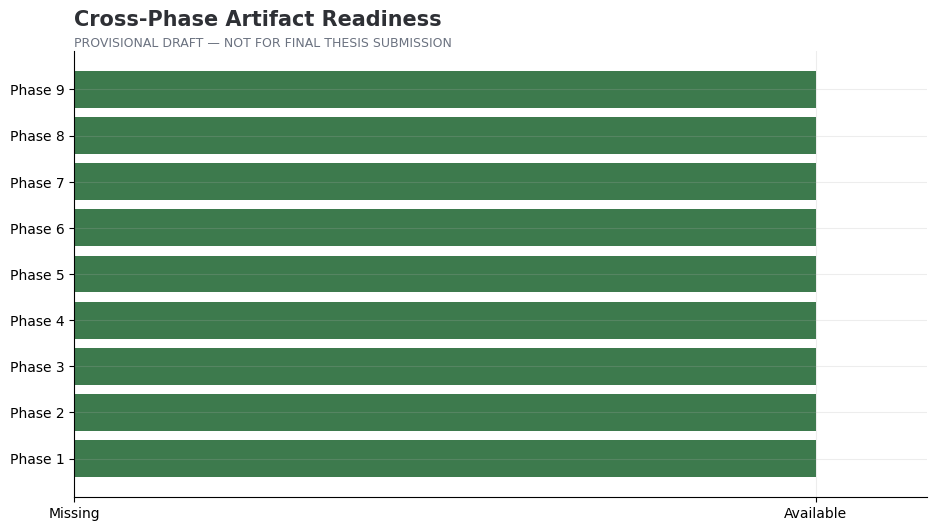

In [5]:
# Cell 10.2.2 — Build Cross-Phase Data-Lineage and Readiness Inventory

phase_status_rows = []
for phase in range(1, 10):
    manifest = manifests.get(phase, {})
    if phase == 1:
        found = any((PROJECT_ROOT / name).exists() for name in ['Phase_01_Consolidated_Reports.xlsx', 'Phase_01_Project_Setup_and_Raw_Data_Understanding.ipynb'])
        completed = 'Phase 1 — Project Setup and Raw Data Understanding' if found else None
        manifest_path = None
    else:
        found = bool(manifest)
        completed = manifest.get('completed_phase')
        manifest_path = manifest_paths.get(phase)
    phase_status_rows.append({
        'phase': f'Phase {phase}',
        'artifact_available': found,
        'completed_phase': completed,
        'manifest_path': str(manifest_path) if manifest_path else None,
        'holdout_used': manifest.get('holdout_test_used', manifest.get('holdout_used')),
        'quality_checks_passed': manifest.get('quality_checks_passed'),
        'generated_at': manifest.get('generated_at'),
    })
phase_inventory = pd.DataFrame(phase_status_rows)

lineage_rows = [
    {'lineage_item': 'Data source', 'value': data_source, 'status': 'Approved' if source_approved else 'Requires explicit approval'},
    {'lineage_item': 'Phase 2 modelling records', 'value': phase_2.get('records'), 'status': 'Recorded'},
    {'lineage_item': 'Training records', 'value': phase_3.get('training_records'), 'status': 'Recorded'},
    {'lineage_item': 'Holdout records', 'value': phase_3.get('holdout_records'), 'status': 'Sealed' if not phase_8_final else 'Evaluated once in Phase 8'},
    {'lineage_item': 'Family overlap', 'value': phase_3.get('family_overlap'), 'status': 'Passed' if int(phase_3.get('family_overlap', 1)) == 0 else 'Failed'},
    {'lineage_item': 'CV folds', 'value': phase_3.get('cv_folds'), 'status': 'Family-aware'},
    {'lineage_item': 'Phase 4 tuning method', 'value': phase_4.get('selection_method', phase_4.get('completed_phase')), 'status': 'Deep tuning frozen' if phase_4_deep else 'Provisional'},
    {'lineage_item': 'Phase 8 status', 'value': phase_8.get('mode'), 'status': 'Final holdout completed' if phase_8_final else 'Holdout not final'},
    {'lineage_item': 'Phase 9 topic review', 'value': phase_9_topics_reviewed, 'status': 'Reviewed' if phase_9_topics_reviewed else 'Researcher review required'},
]
lineage_summary = pd.DataFrame(lineage_rows)

FOLDERS = create_cell_folders('10_02', 'Governance_and_Lineage', '10_02_02', 'Phase_Readiness_and_Lineage')
save_dataframe(phase_inventory, FOLDERS, '10_02_02_phase_inventory')
save_dataframe(lineage_summary, FOLDERS, '10_02_02_lineage_summary')
display(phase_inventory)
display(lineage_summary)

fig, ax = plt.subplots(figsize=(11, 5.8))
status_values = phase_inventory['artifact_available'].astype(int)
ax.barh(phase_inventory['phase'], status_values, color=[THEME['green'] if x else THEME['red'] for x in status_values])
ax.set_xlim(0, 1.15)
ax.set_xticks([0, 1], ['Missing', 'Available'])
style_axis(ax, 'Cross-Phase Artifact Readiness', DRAFT_BANNER, grid_axis='x')
save_figure(fig, FOLDERS, '10_02_02_phase_readiness')
plt.show()


# Section 10.3 — Dataset and Experimental Design Synthesis


,measure,value
0,Data source,SYNTHETIC
1,Cleaned modelling records,2500
2,Training records,2006
3,Holdout records,494
4,Training families,984
5,Holdout families,254
6,Predictor count,17
7,Target classes,"Low, Medium, High"
8,Cross-validation folds,5
9,Primary metric,f1_macro


,academic_class,records,percentage
0,Medium,993,49.501496
1,Low,510,25.423729
2,High,503,25.074776


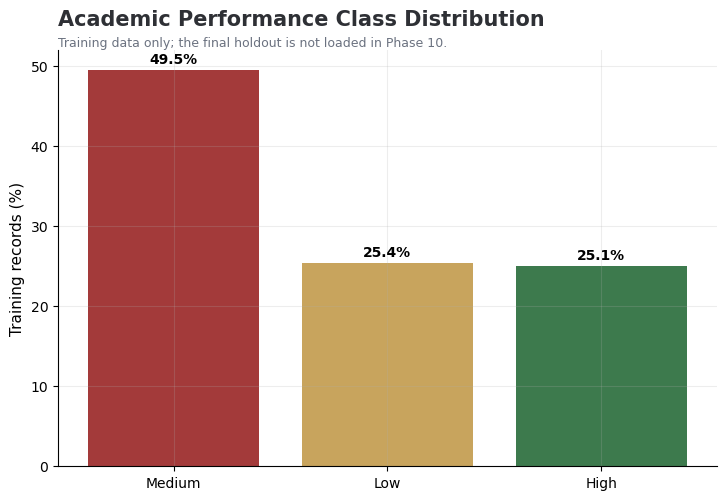

In [6]:
# Cell 10.3.1 — Create Dataset Profile and Class-Distribution Tables

MODELLING_DATA_PATH = resolve_artifact(
    phase_2.get('primary_input_for_phase_3'),
    ['data/phase_02_modelling_dataset_for_phase_03.csv', 'phase_02_modelling_dataset_for_phase_03.csv'],
)
TRAINING_DATA_PATH = resolve_artifact(
    phase_3.get('primary_training_dataset_for_phase_4'),
    ['data/phase_03_training_dataset_for_phase_04.csv', 'phase_03_training_dataset_for_phase_04.csv'],
)

modelling_data = load_table(MODELLING_DATA_PATH) if MODELLING_DATA_PATH else pd.DataFrame()
training_data = load_table(TRAINING_DATA_PATH) if TRAINING_DATA_PATH else pd.DataFrame()
target_column = phase_3.get('target_column', phase_2.get('target_column', 'academic_performance_class'))
group_column = phase_3.get('group_column', phase_2.get('group_column', 'family_id'))
predictor_columns = phase_3.get('predictor_columns', phase_2.get('predictor_columns', []))

profile_rows = [
    {'measure': 'Data source', 'value': data_source},
    {'measure': 'Cleaned modelling records', 'value': len(modelling_data) if not modelling_data.empty else phase_2.get('records')},
    {'measure': 'Training records', 'value': len(training_data) if not training_data.empty else phase_3.get('training_records')},
    {'measure': 'Holdout records', 'value': phase_3.get('holdout_records')},
    {'measure': 'Training families', 'value': training_data[group_column].nunique() if group_column in training_data else phase_3.get('training_families')},
    {'measure': 'Holdout families', 'value': phase_3.get('holdout_families')},
    {'measure': 'Predictor count', 'value': len(predictor_columns)},
    {'measure': 'Target classes', 'value': ', '.join(phase_3.get('target_classes', ['Low', 'Medium', 'High']))},
    {'measure': 'Cross-validation folds', 'value': phase_3.get('cv_folds')},
    {'measure': 'Primary metric', 'value': phase_3.get('primary_metric')},
    {'measure': 'Family overlap', 'value': phase_3.get('family_overlap')},
]
dataset_profile = pd.DataFrame(profile_rows)

if target_column in training_data.columns:
    class_distribution = training_data[target_column].value_counts(dropna=False).rename_axis('academic_class').reset_index(name='records')
    class_distribution['percentage'] = class_distribution['records'] / class_distribution['records'].sum() * 100
else:
    class_distribution = pd.DataFrame(columns=['academic_class', 'records', 'percentage'])

FOLDERS = create_cell_folders('10_03', 'Dataset_and_Experimental_Design', '10_03_01', 'Dataset_Profile')
save_dataframe(dataset_profile, FOLDERS, '10_03_01_dataset_profile')
save_dataframe(class_distribution, FOLDERS, '10_03_01_training_class_distribution')
display(dataset_profile)
display(class_distribution)

if not class_distribution.empty:
    fig, ax = plt.subplots(figsize=(8.5, 5.4))
    bars = ax.bar(class_distribution['academic_class'], class_distribution['percentage'], color=[THEME['red'], THEME['gold'], THEME['green']][:len(class_distribution)])
    for bar, value in zip(bars, class_distribution['percentage']):
        ax.text(bar.get_x() + bar.get_width()/2, value + 0.8, f'{value:.1f}%', ha='center', fontweight='bold')
    ax.set_ylabel('Training records (%)')
    style_axis(ax, 'Academic Performance Class Distribution', 'Training data only; the final holdout is not loaded in Phase 10.')
    save_figure(fig, FOLDERS, '10_03_01_class_distribution')
    plt.show()


# Section 10.4 — Supervised Learning and Model-Quality Integration


In [7]:
# Cell 10.4.1 — Load Phase 4 and Phase 6 Performance Tables


def find_table_from_manifest(manifest, key, fallback_names=()):
    return resolve_artifact(manifest.get(key), fallback_names)

PHASE_4_LEADERBOARD_PATH = find_table_from_manifest(
    phase_4, 'leaderboard',
    ['data/phase_04_supervised_model_leaderboard.csv', 'phase_04_supervised_model_leaderboard.csv'],
)
PHASE_6_LEADERBOARD_PATH = find_table_from_manifest(
    phase_6, 'candidate_leaderboard',
    ['data/phase_06_candidate_model_leaderboard.csv', 'phase_06_candidate_model_leaderboard.csv'],
)
PHASE_6_SELECTION_PATH = find_table_from_manifest(
    phase_6, 'candidate_selection',
    ['data/phase_06_multi_criteria_candidate_selection.csv', 'phase_06_multi_criteria_candidate_selection.csv'],
)
PHASE_6_BOOTSTRAP_PATH = find_table_from_manifest(
    phase_6, 'bootstrap_confidence_intervals',
    ['data/phase_06_bootstrap_confidence_intervals.csv', 'phase_06_bootstrap_confidence_intervals.csv'],
)
PHASE_6_FAIRNESS_PATH = find_table_from_manifest(
    phase_6, 'fairness_gaps',
    ['data/phase_06_fairness_gaps.csv', 'phase_06_fairness_gaps.csv'],
)

phase_4_leaderboard = load_table(PHASE_4_LEADERBOARD_PATH) if PHASE_4_LEADERBOARD_PATH else pd.DataFrame()
phase_6_leaderboard = load_table(PHASE_6_LEADERBOARD_PATH) if PHASE_6_LEADERBOARD_PATH else pd.DataFrame()
phase_6_selection = load_table(PHASE_6_SELECTION_PATH) if PHASE_6_SELECTION_PATH else pd.DataFrame()
phase_6_bootstrap = load_table(PHASE_6_BOOTSTRAP_PATH) if PHASE_6_BOOTSTRAP_PATH else pd.DataFrame()
phase_6_fairness = load_table(PHASE_6_FAIRNESS_PATH) if PHASE_6_FAIRNESS_PATH else pd.DataFrame()

primary_model_table = phase_6_selection if not phase_6_selection.empty else (phase_6_leaderboard if not phase_6_leaderboard.empty else phase_4_leaderboard)

metric_candidates = {
    'Accuracy': ['mean_accuracy', 'accuracy'],
    'Balanced Accuracy': ['mean_balanced_accuracy', 'balanced_accuracy'],
    'Macro Precision': ['mean_precision_macro', 'precision_macro'],
    'Macro Recall': ['mean_recall_macro', 'recall_macro'],
    'Macro F1': ['mean_f1_macro', 'macro_f1_mean', 'f1_macro'],
    'Weighted F1': ['mean_f1_weighted', 'f1_weighted'],
    'ROC-AUC': ['mean_roc_auc_ovr_weighted', 'roc_auc_ovr_weighted'],
    'Log Loss': ['mean_multiclass_log_loss', 'multiclass_log_loss'],
}

def first_column(frame, candidates):
    return next((column for column in candidates if column in frame.columns), None)

rows=[]
if not primary_model_table.empty:
    for _, row in primary_model_table.head(TOP_MODELS_TO_REPORT).iterrows():
        item = {
            'model': row.get('model'),
            'stage': row.get('stage'),
            'rank': row.get('finalist_rank', row.get('rank', row.get('phase_6_initial_rank'))),
            'selected_for_finalist': row.get('selected_for_phase_7', row.get('selected_for_phase_6')),
        }
        for display_name, candidates in metric_candidates.items():
            column = first_column(primary_model_table, candidates)
            item[display_name] = row.get(column) if column else np.nan
        rows.append(item)
model_performance_summary = pd.DataFrame(rows)

FOLDERS = create_cell_folders('10_04', 'Supervised_Model_Integration', '10_04_01', 'Load_Performance_Tables')
save_dataframe(model_performance_summary, FOLDERS, '10_04_01_model_performance_summary')
display(model_performance_summary)


,model,stage,rank,selected_for_finalist,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC,Log Loss
0,Logistic Regression,Baseline,1,True,0.589031,0.538339,0.603703,0.538339,0.552795,0.576821,0.709415,0.859817
1,Random Forest,Tuned,2,True,0.536842,0.568098,0.536825,0.568098,0.541911,0.534011,0.701863,0.903673
2,CatBoost,Tuned,3,True,0.576003,0.529519,0.582049,0.529519,0.541645,0.565144,0.702165,0.881316
3,Multi-Layer Perceptron,Tuned,4,False,0.574925,0.532701,0.573074,0.532701,0.540982,0.563676,0.706195,0.864272


In [8]:
# Cell 10.4.2 — Reconstruct Baseline-versus-Tuned Comparisons

PHASE_4_SUMMARY_PATH = find_table_from_manifest(
    phase_4, 'summary_results',
    ['data/phase_04_all_summary_results.csv', 'phase_04_all_summary_results.csv'],
)
phase_4_summaries = load_table(PHASE_4_SUMMARY_PATH) if PHASE_4_SUMMARY_PATH else pd.DataFrame()

# Fallback to the consolidated Phase 4 workbook when portable CSVs are absent.
if phase_4_summaries.empty:
    workbook_path = resolve_artifact(None, ['Phase_04_Consolidated_Reports.xlsx'])
    if workbook_path:
        try:
            sheets = pd.read_excel(workbook_path, sheet_name=None)
            for sheet_name, frame in sheets.items():
                lower = sheet_name.lower().replace(' ', '_')
                if 'summary' in lower and {'model', 'stage'}.issubset(set(frame.columns)):
                    phase_4_summaries = frame
                    break
        except Exception as exc:
            print('Phase 4 workbook fallback could not be read:', exc)

comparison_metrics = [
    'mean_accuracy', 'mean_balanced_accuracy', 'mean_precision_macro',
    'mean_recall_macro', 'mean_f1_macro', 'mean_f1_weighted',
    'mean_recall_low', 'mean_recall_medium', 'mean_recall_high',
    'mean_f1_low', 'mean_f1_medium', 'mean_f1_high',
]
comparison_rows=[]
if not phase_4_summaries.empty and {'model', 'stage'}.issubset(phase_4_summaries.columns):
    working = phase_4_summaries[phase_4_summaries['model'].astype(str) != 'Dummy Baseline'].copy()
    for model, group in working.groupby('model'):
        baseline_rows = group[group['stage'].astype(str).str.lower() == 'baseline']
        tuned_rows = group[group['stage'].astype(str).str.lower() == 'tuned']
        if baseline_rows.empty or tuned_rows.empty:
            continue
        base = baseline_rows.iloc[0]
        tuned = tuned_rows.iloc[0]
        for metric in comparison_metrics:
            if metric not in group.columns:
                continue
            baseline_value = pd.to_numeric(pd.Series([base.get(metric)]), errors='coerce').iloc[0]
            tuned_value = pd.to_numeric(pd.Series([tuned.get(metric)]), errors='coerce').iloc[0]
            comparison_rows.append({
                'model': model,
                'metric': metric.replace('mean_', ''),
                'baseline': baseline_value,
                'tuned': tuned_value,
                'tuned_minus_baseline': tuned_value - baseline_value,
                'improved': bool(tuned_value > baseline_value),
            })
baseline_tuned_comparison = pd.DataFrame(comparison_rows)

if not baseline_tuned_comparison.empty:
    tuning_model_summary = baseline_tuned_comparison.groupby('model').agg(
        metrics_compared=('metric', 'count'),
        metrics_improved=('improved', 'sum'),
        mean_beneficial_change=('tuned_minus_baseline', 'mean'),
    ).reset_index()
    tuning_model_summary['percentage_metrics_improved'] = tuning_model_summary['metrics_improved'] / tuning_model_summary['metrics_compared'] * 100
else:
    tuning_model_summary = pd.DataFrame(columns=['model', 'metrics_compared', 'metrics_improved', 'mean_beneficial_change', 'percentage_metrics_improved'])

FOLDERS = create_cell_folders('10_04', 'Supervised_Model_Integration', '10_04_02', 'Baseline_vs_Tuned')
save_dataframe(baseline_tuned_comparison, FOLDERS, '10_04_02_baseline_vs_tuned_metric_comparison')
save_dataframe(tuning_model_summary, FOLDERS, '10_04_02_tuning_improvement_summary')
display(tuning_model_summary)


,model,metrics_compared,metrics_improved,mean_beneficial_change,percentage_metrics_improved
0,CatBoost,12,11,0.008585,91.666667
1,Decision Tree,12,9,0.039444,75.000000
2,Gradient Boosting,12,10,0.001482,83.333333
3,K-Nearest Neighbours,12,9,0.033041,75.000000
4,Logistic Regression,12,3,-0.030749,25.000000
5,Multi-Layer Perceptron,12,9,0.014534,75.000000
6,Random Forest,12,7,0.024422,58.333333
7,Support Vector Machine,12,6,-0.012188,50.000000
8,XGBoost,12,10,0.016385,83.333333


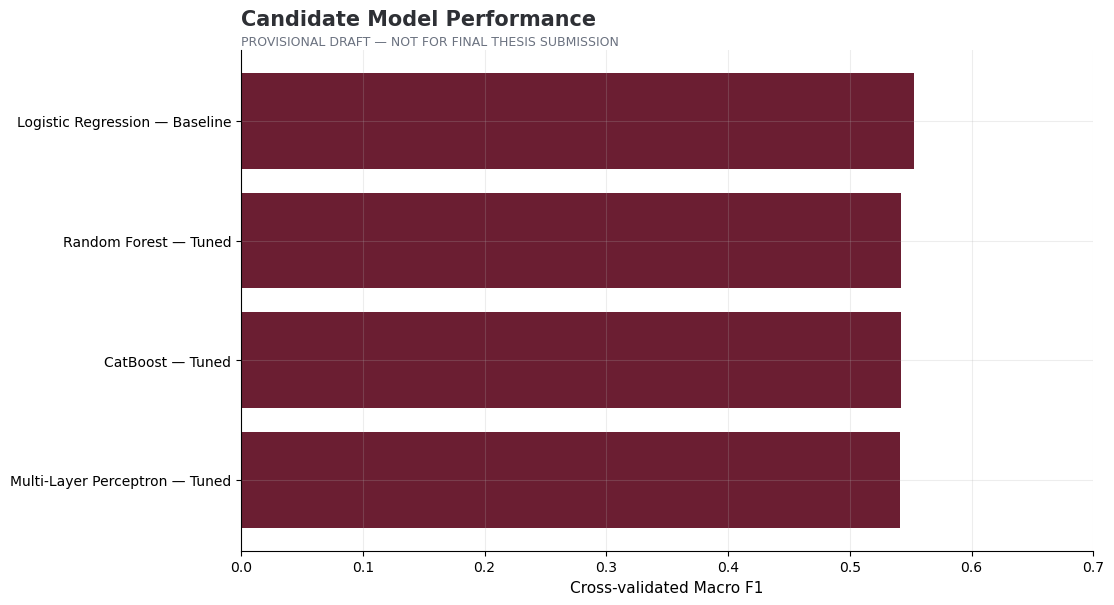

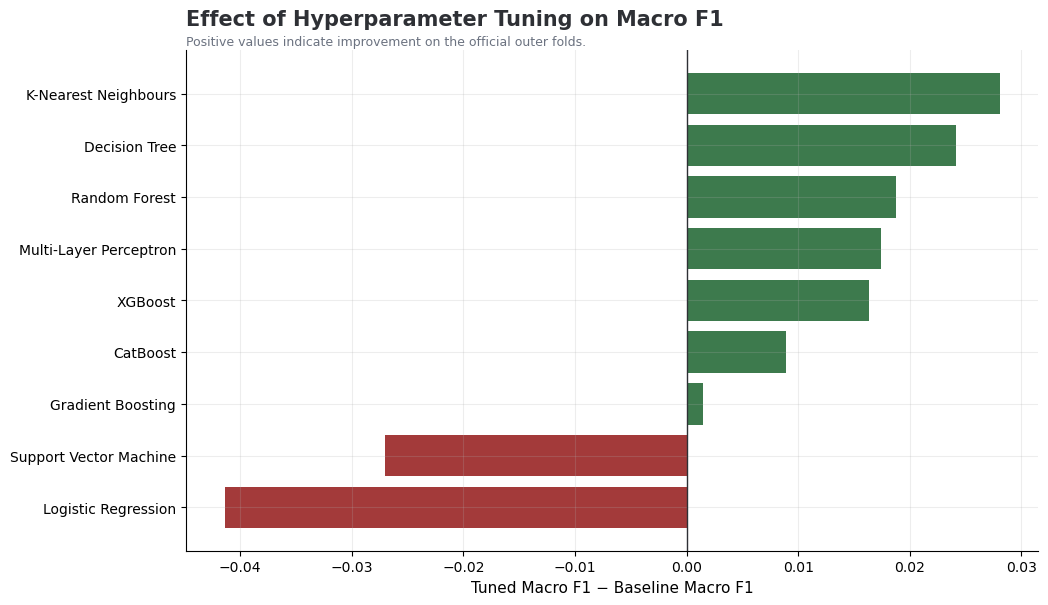

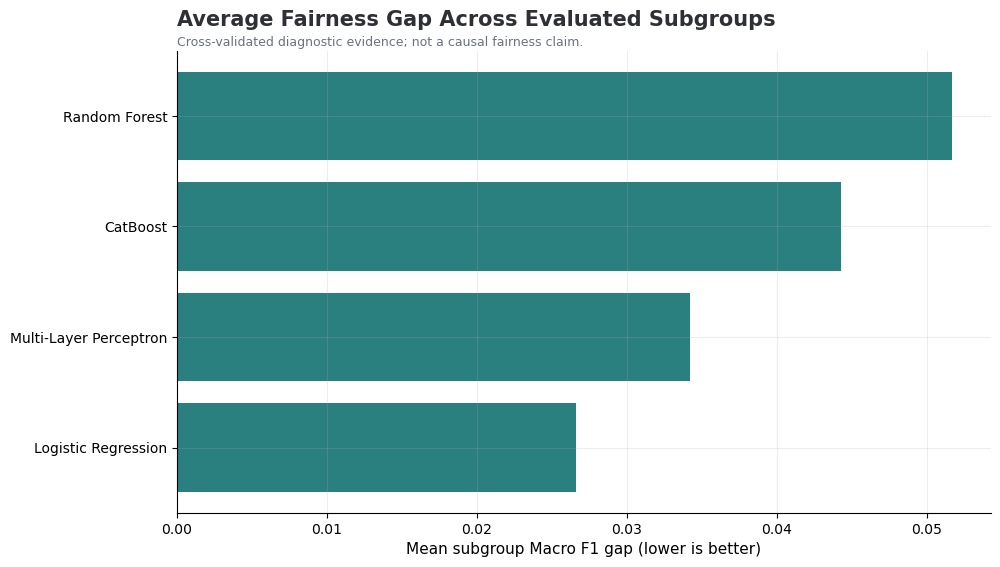

[WindowsPath('C:/Users/User/Desktop/All/outputs/Phase_10_Final_Results_Integration_and_Thesis_Reporting/Section_10_04_Supervised_Model_Integration/Cell_10_04_03_Supervised_Visualisations/tables/10_04_03_visualisation_catalogue.csv')]

In [9]:
# Cell 10.4.3 — Visualise Model Performance, Tuning Effects, and Fairness

FOLDERS = create_cell_folders('10_04', 'Supervised_Model_Integration', '10_04_03', 'Supervised_Visualisations')
visualisation_rows=[]

if not model_performance_summary.empty and 'Macro F1' in model_performance_summary:
    plot_data = model_performance_summary.sort_values('Macro F1', ascending=True)
    fig, ax = plt.subplots(figsize=(11, 6.5))
    labels = plot_data['model'].astype(str) + ' — ' + plot_data['stage'].astype(str)
    ax.barh(labels, plot_data['Macro F1'], color=THEME['maroon'])
    ax.set_xlim(0, max(0.7, float(plot_data['Macro F1'].max()) + 0.08))
    ax.set_xlabel('Cross-validated Macro F1')
    style_axis(ax, 'Candidate Model Performance', DRAFT_BANNER, grid_axis='x')
    path = save_figure(fig, FOLDERS, '10_04_03_candidate_macro_f1')
    visualisation_rows.append({'figure': 'Candidate model Macro F1', 'path': str(path), 'thesis_section': 'Results — supervised model comparison'})
    plt.show()

if not baseline_tuned_comparison.empty:
    macro = baseline_tuned_comparison[baseline_tuned_comparison['metric'] == 'f1_macro'].copy()
    if not macro.empty:
        macro = macro.sort_values('tuned_minus_baseline')
        fig, ax = plt.subplots(figsize=(11, 6.5))
        colors = [THEME['green'] if value > 0 else THEME['red'] for value in macro['tuned_minus_baseline']]
        ax.barh(macro['model'], macro['tuned_minus_baseline'], color=colors)
        ax.axvline(0, color=THEME['charcoal'], linewidth=1)
        ax.set_xlabel('Tuned Macro F1 − Baseline Macro F1')
        style_axis(ax, 'Effect of Hyperparameter Tuning on Macro F1', 'Positive values indicate improvement on the official outer folds.', grid_axis='x')
        path = save_figure(fig, FOLDERS, '10_04_03_macro_f1_tuning_effect')
        visualisation_rows.append({'figure': 'Macro F1 tuning effect', 'path': str(path), 'thesis_section': 'Results — baseline versus tuned'})
        plt.show()

if not phase_6_fairness.empty and {'model', 'subgroup_variable', 'macro_f1_gap'}.issubset(phase_6_fairness.columns):
    fairness_plot = phase_6_fairness.groupby('model', as_index=False)['macro_f1_gap'].mean().sort_values('macro_f1_gap')
    fig, ax = plt.subplots(figsize=(10.5, 6))
    ax.barh(fairness_plot['model'], fairness_plot['macro_f1_gap'], color=THEME['teal'])
    ax.set_xlabel('Mean subgroup Macro F1 gap (lower is better)')
    style_axis(ax, 'Average Fairness Gap Across Evaluated Subgroups', 'Cross-validated diagnostic evidence; not a causal fairness claim.', grid_axis='x')
    path = save_figure(fig, FOLDERS, '10_04_03_mean_fairness_gap')
    visualisation_rows.append({'figure': 'Mean subgroup fairness gap', 'path': str(path), 'thesis_section': 'Results — robustness and fairness'})
    plt.show()

supervised_visualisations = pd.DataFrame(visualisation_rows)
save_dataframe(supervised_visualisations, FOLDERS, '10_04_03_visualisation_catalogue')


# Section 10.5 — Unsupervised Learning Integration


,measure,value
0,Selected cluster count,3
1,Silhouette score,0.179916
2,Calinski–Harabasz score,486.11354
3,Davies–Bouldin score,1.662944
4,Mean stability ARI,0.953214
5,Cramér's V with academic class,0.294794
6,Target used during clustering,False


,cluster_name,Low,Medium,High
0,Cluster 1 — Higher relative support,12.016575,49.585635,38.397790
1,Cluster 2 — Moderate relative support,19.463087,54.496644,26.040268
2,Cluster 3 — Lower relative support,51.769088,42.458101,5.772812


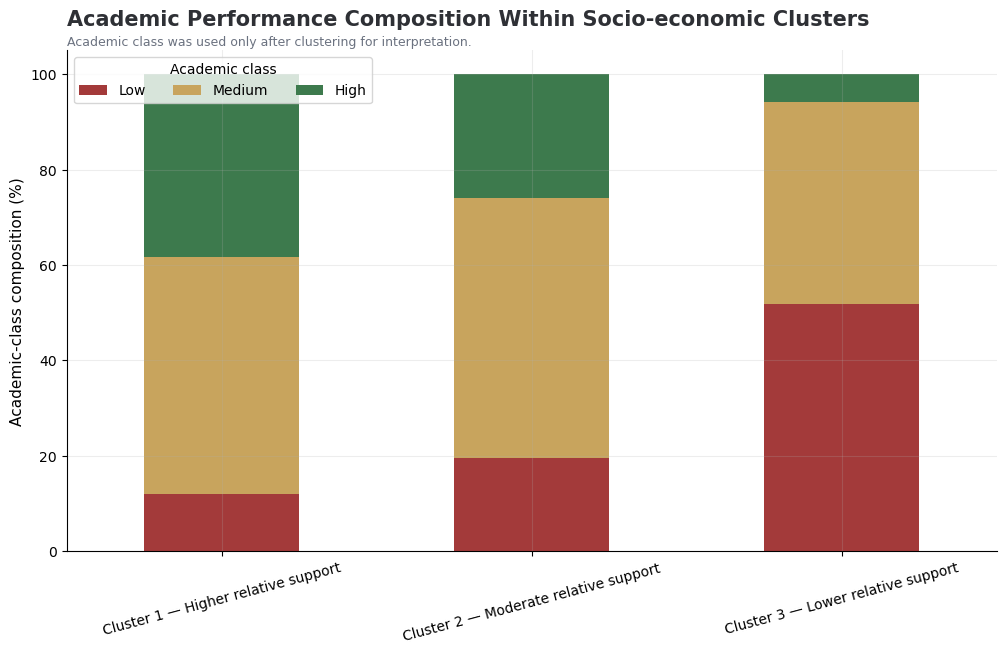

In [10]:
# Cell 10.5.1 — Integrate Cluster Profiles, Target Composition, and Stability

CLUSTER_ASSIGNMENTS_PATH = find_table_from_manifest(phase_5, 'cluster_assignments', ['data/phase_05_cluster_assignments.csv'])
CLUSTER_PROFILES_PATH = find_table_from_manifest(phase_5, 'cluster_profiles', ['data/phase_05_cluster_profiles.csv'])
CLUSTER_TARGET_PATH = find_table_from_manifest(phase_5, 'cluster_target_comparison', ['data/phase_05_cluster_target_comparison.csv'])
CLUSTER_EVAL_PATH = find_table_from_manifest(phase_5, 'cluster_evaluation', ['data/phase_05_cluster_evaluation.csv'])

cluster_assignments = load_table(CLUSTER_ASSIGNMENTS_PATH) if CLUSTER_ASSIGNMENTS_PATH else pd.DataFrame()
cluster_profiles = load_table(CLUSTER_PROFILES_PATH) if CLUSTER_PROFILES_PATH else pd.DataFrame()
cluster_target_comparison = load_table(CLUSTER_TARGET_PATH) if CLUSTER_TARGET_PATH else pd.DataFrame()
cluster_evaluation = load_table(CLUSTER_EVAL_PATH) if CLUSTER_EVAL_PATH else pd.DataFrame()

if not cluster_assignments.empty and 'cluster_name' in cluster_assignments:
    cluster_sizes = cluster_assignments['cluster_name'].value_counts().rename_axis('cluster_name').reset_index(name='records')
    cluster_sizes['percentage'] = cluster_sizes['records'] / cluster_sizes['records'].sum() * 100
else:
    cluster_sizes = pd.DataFrame(columns=['cluster_name', 'records', 'percentage'])

cluster_method_summary = pd.DataFrame([
    {'measure': 'Selected cluster count', 'value': phase_5.get('selected_cluster_count')},
    {'measure': 'Silhouette score', 'value': phase_5.get('silhouette_score')},
    {'measure': 'Calinski–Harabasz score', 'value': phase_5.get('calinski_harabasz_score')},
    {'measure': 'Davies–Bouldin score', 'value': phase_5.get('davies_bouldin_score')},
    {'measure': 'Mean stability ARI', 'value': phase_5.get('mean_stability_ari')},
    {'measure': "Cramér's V with academic class", 'value': phase_5.get('cramers_v_with_academic_class')},
    {'measure': 'Target used during clustering', 'value': phase_5.get('target_used_during_clustering')},
])

FOLDERS = create_cell_folders('10_05', 'Unsupervised_Integration', '10_05_01', 'Cluster_Synthesis')
for name, frame in [
    ('10_05_01_cluster_sizes', cluster_sizes),
    ('10_05_01_cluster_profiles', cluster_profiles),
    ('10_05_01_cluster_target_comparison', cluster_target_comparison),
    ('10_05_01_cluster_method_summary', cluster_method_summary),
]:
    save_dataframe(frame, FOLDERS, name)

display(cluster_method_summary)
display(cluster_target_comparison)

if not cluster_target_comparison.empty:
    plot = cluster_target_comparison.set_index('cluster_name')
    class_columns = [column for column in ['Low', 'Medium', 'High'] if column in plot.columns]
    fig, ax = plt.subplots(figsize=(12, 6.5))
    plot[class_columns].plot(kind='bar', stacked=True, ax=ax, color=[THEME['red'], THEME['gold'], THEME['green']][:len(class_columns)])
    ax.set_ylabel('Academic-class composition (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    style_axis(ax, 'Academic Performance Composition Within Socio-economic Clusters', 'Academic class was used only after clustering for interpretation.')
    ax.legend(title='Academic class', ncol=3)
    save_figure(fig, FOLDERS, '10_05_01_cluster_target_composition')
    plt.show()


# Section 10.6 — Explainability Integration


,consensus_rank,feature,consensus_importance,importance_standard_deviation,mean_rank,rank_standard_deviation,contributing_model_method_pairs,feature_group
0,1,family_income,0.199872,0.077530,1.666667,1.322876,9,Occupation and Income
1,2,father_education,0.174366,0.053715,2.333333,1.802776,9,Parental Education
2,3,mother_education,0.098718,0.036136,4.444444,2.351123,9,Parental Education
3,4,tutoring_support,0.071409,0.020131,5.111111,1.964971,9,Support and Lifestyle
4,5,father_job,0.066878,0.049784,7.222222,2.682246,9,Occupation and Income
5,6,mother_job,0.059465,0.022244,7.333333,2.692582,9,Occupation and Income
6,7,daily_smart_device_usage,0.056365,0.022703,6.888889,3.218868,9,Support and Lifestyle
7,8,number_of_children,0.050223,0.023791,8.111111,2.976762,9,Family Structure
8,9,chronic_disease,0.047308,0.017548,8.111111,2.713137,9,Support and Lifestyle
9,10,marital_status,0.043208,0.054506,10.333333,3.840573,9,Family Structure


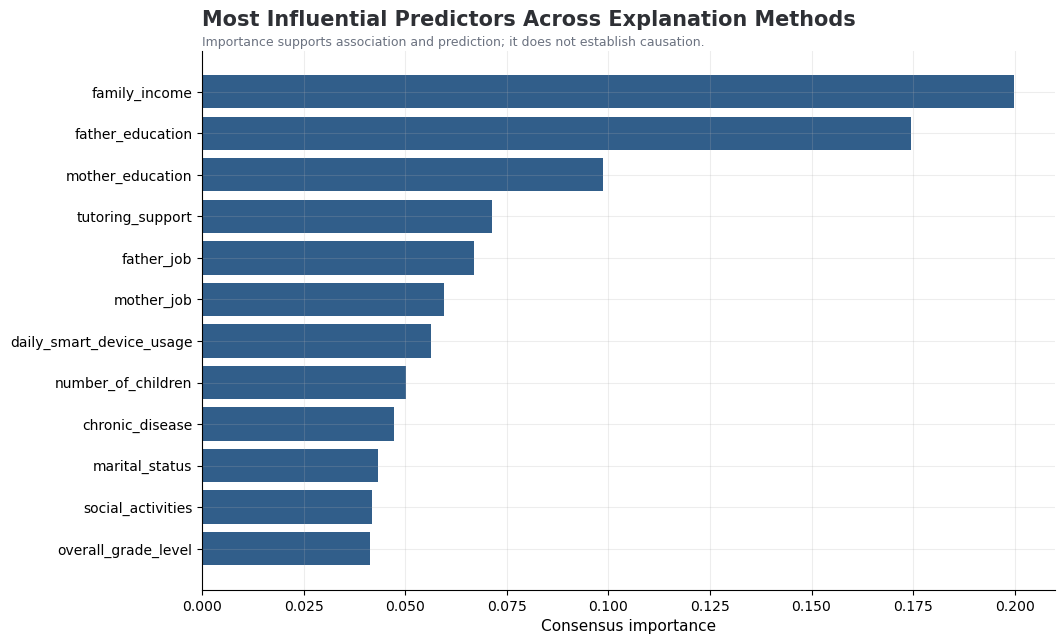

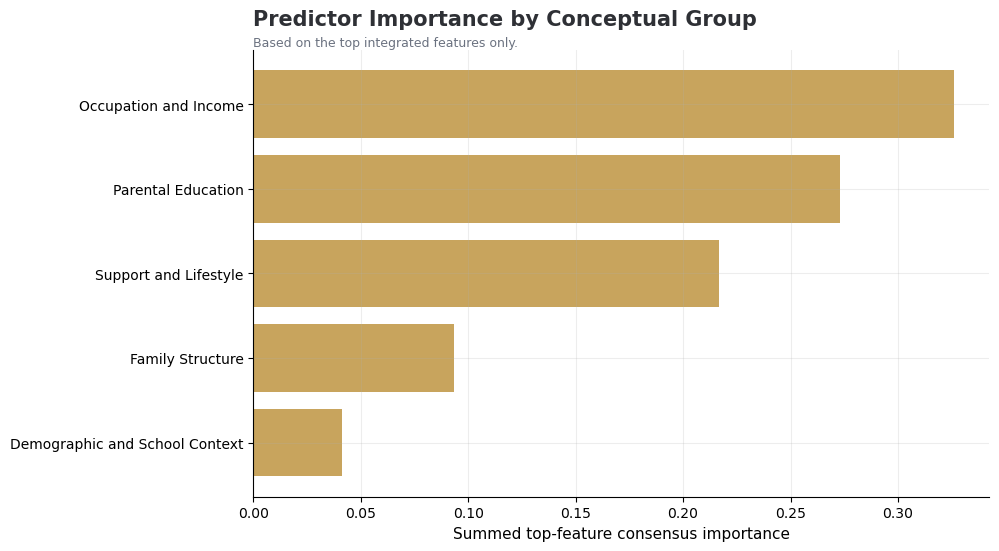

In [11]:
# Cell 10.6.1 — Integrate Global, Class-Specific, and Cluster-Specific Explanations

CONSENSUS_IMPORTANCE_PATH = find_table_from_manifest(phase_7, 'consensus_feature_importance', ['data/phase_07_consensus_feature_importance.csv'])
SHAP_CLASS_PATH = find_table_from_manifest(phase_7, 'shap_class_importance', ['data/phase_07_shap_class_importance.csv'])
CLUSTER_IMPORTANCE_PATH = find_table_from_manifest(phase_7, 'cluster_specific_importance', ['data/phase_07_cluster_specific_importance.csv'])
FEATURE_EFFECTS_PATH = find_table_from_manifest(phase_7, 'feature_effects', ['data/phase_07_feature_effects.csv'])

consensus_importance = load_table(CONSENSUS_IMPORTANCE_PATH) if CONSENSUS_IMPORTANCE_PATH else pd.DataFrame()
shap_class_importance = load_table(SHAP_CLASS_PATH) if SHAP_CLASS_PATH else pd.DataFrame()
cluster_specific_importance = load_table(CLUSTER_IMPORTANCE_PATH) if CLUSTER_IMPORTANCE_PATH else pd.DataFrame()
feature_effects = load_table(FEATURE_EFFECTS_PATH) if FEATURE_EFFECTS_PATH else pd.DataFrame()

top_features = consensus_importance.head(TOP_FEATURES_TO_REPORT).copy() if not consensus_importance.empty else pd.DataFrame()

FOLDERS = create_cell_folders('10_06', 'Explainability_Integration', '10_06_01', 'Feature_Importance_Synthesis')
for name, frame in [
    ('10_06_01_top_consensus_features', top_features),
    ('10_06_01_class_specific_importance', shap_class_importance),
    ('10_06_01_cluster_specific_importance', cluster_specific_importance),
    ('10_06_01_feature_effects', feature_effects),
]:
    save_dataframe(frame, FOLDERS, name)

display(top_features)

if not top_features.empty and {'feature', 'consensus_importance'}.issubset(top_features.columns):
    plot = top_features.sort_values('consensus_importance')
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(plot['feature'], plot['consensus_importance'], color=THEME['blue'])
    ax.set_xlabel('Consensus importance')
    style_axis(ax, 'Most Influential Predictors Across Explanation Methods', 'Importance supports association and prediction; it does not establish causation.', grid_axis='x')
    save_figure(fig, FOLDERS, '10_06_01_top_consensus_features')
    plt.show()

if not top_features.empty and 'feature_group' in top_features:
    group_summary = top_features.groupby('feature_group', as_index=False)['consensus_importance'].sum().sort_values('consensus_importance')
    fig, ax = plt.subplots(figsize=(9.5, 5.8))
    ax.barh(group_summary['feature_group'], group_summary['consensus_importance'], color=THEME['gold'])
    ax.set_xlabel('Summed top-feature consensus importance')
    style_axis(ax, 'Predictor Importance by Conceptual Group', 'Based on the top integrated features only.', grid_axis='x')
    save_figure(fig, FOLDERS, '10_06_01_feature_group_importance')
    plt.show()


# Section 10.7 — Final Holdout Evaluation Integration


In [12]:
# Cell 10.7.1 — Load Final Phase 8 Results without Accessing Raw Holdout Data

final_metrics = pd.DataFrame()
per_class_metrics = pd.DataFrame()
cv_holdout_comparison = pd.DataFrame()
bootstrap_holdout = pd.DataFrame()
subgroup_holdout = pd.DataFrame()

if phase_8_final:
    output_keys = phase_8.get('official_outputs', [])
    def find_official(basename):
        matching = [item for item in output_keys if Path(str(item)).name == basename]
        return resolve_artifact(matching[0] if matching else None, [f'data/{basename}', basename])
    table_map = {
        'final_metrics': 'phase_08_final_metrics.csv',
        'per_class_metrics': 'phase_08_per_class_metrics.csv',
        'cv_holdout_comparison': 'phase_08_cv_holdout_comparison.csv',
        'bootstrap_holdout': 'phase_08_bootstrap_confidence_intervals.csv',
        'subgroup_holdout': 'phase_08_subgroup_gaps.csv',
    }
    loaded = {}
    for key, basename in table_map.items():
        path = find_official(basename)
        loaded[key] = load_table(path) if path else pd.DataFrame()
    final_metrics = loaded['final_metrics']
    per_class_metrics = loaded['per_class_metrics']
    cv_holdout_comparison = loaded['cv_holdout_comparison']
    bootstrap_holdout = loaded['bootstrap_holdout']
    subgroup_holdout = loaded['subgroup_holdout']
    holdout_reporting_status = 'FINAL HOLDOUT RESULTS AVAILABLE'
else:
    holdout_reporting_status = 'BLOCKED — PHASE 8 FINAL HOLDOUT HAS NOT BEEN COMPLETED'

holdout_status = pd.DataFrame([
    {'item': 'Phase 8 mode', 'value': phase_8.get('mode')},
    {'item': 'Final evaluation completed', 'value': phase_8.get('final_evaluation_completed')},
    {'item': 'Holdout used', 'value': phase_8.get('holdout_used')},
    {'item': 'Locked model', 'value': phase_8.get('locked_model')},
    {'item': 'Locked stage', 'value': phase_8.get('locked_stage')},
    {'item': 'Reporting status', 'value': holdout_reporting_status},
])

FOLDERS = create_cell_folders('10_07', 'Final_Holdout_Integration', '10_07_01', 'Final_Holdout_Results')
for name, frame in [
    ('10_07_01_holdout_status', holdout_status),
    ('10_07_01_final_metrics', final_metrics),
    ('10_07_01_per_class_metrics', per_class_metrics),
    ('10_07_01_cv_holdout_comparison', cv_holdout_comparison),
    ('10_07_01_bootstrap_confidence_intervals', bootstrap_holdout),
    ('10_07_01_subgroup_gaps', subgroup_holdout),
]:
    save_dataframe(frame, FOLDERS, name)

display(holdout_status)
if phase_8_final:
    display(final_metrics)
    display(per_class_metrics)
else:
    print(holdout_reporting_status)


,item,value
0,Phase 8 mode,DRY_RUN
1,Final evaluation completed,False
2,Holdout used,False
3,Locked model,Logistic Regression
4,Locked stage,Baseline
5,Reporting status,BLOCKED — PHASE 8 FINAL HOLDOUT HAS NOT BEEN C...


BLOCKED — PHASE 8 FINAL HOLDOUT HAS NOT BEEN COMPLETED


In [13]:
# Cell 10.7.2 — Visualise Final Holdout Metrics When the Governance Gate Is Open

FOLDERS = create_cell_folders('10_07', 'Final_Holdout_Integration', '10_07_02', 'Holdout_Visualisations')

if phase_8_final and not final_metrics.empty:
    higher_is_better = final_metrics[final_metrics['metric'].isin([
        'accuracy', 'balanced_accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted', 'roc_auc_ovr_macro'
    ])].copy()
    fig, ax = plt.subplots(figsize=(11, 6.3))
    ax.bar(higher_is_better['metric'], higher_is_better['value'], color=THEME['green'])
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=25)
    ax.set_ylabel('Final holdout score')
    style_axis(ax, 'Final Holdout Evaluation', 'The model was frozen before the holdout was opened once.')
    save_figure(fig, FOLDERS, '10_07_02_final_holdout_metrics')
    plt.show()

    if not per_class_metrics.empty:
        plot = per_class_metrics.set_index('class')
        fig, ax = plt.subplots(figsize=(9.5, 6))
        plot[['precision', 'recall', 'f1_score']].plot(kind='bar', ax=ax, color=[THEME['blue'], THEME['gold'], THEME['maroon']])
        ax.set_ylim(0, 1)
        ax.set_ylabel('Score')
        ax.tick_params(axis='x', rotation=0)
        style_axis(ax, 'Final Per-Class Performance', 'Precision, Recall, and F1-score on the untouched holdout.')
        save_figure(fig, FOLDERS, '10_07_02_final_per_class_metrics')
        plt.show()
else:
    print('Final holdout visualisations were not generated because Phase 8 remains incomplete or provisional.')


Final holdout visualisations were not generated because Phase 8 remains incomplete or provisional.


# Section 10.8 — Open-Ended Response and NLP Integration


,question_column,question_label,total_records,substantive_responses,missing_responses,non_substantive_responses,too_short_responses,possible_pii_responses,median_character_count,median_analysis_tokens,substantive_response_rate
0,additional_suggestions,Additional suggestions,2500,1397,731,372,0,0,29.0,4.0,0.5588
1,other_influencing_factors,Other influencing factors,2500,1660,543,297,0,0,27.0,4.0,0.6640


,topic_id,automatic_topic_label,response_count,mean_topic_confidence,median_topic_confidence,unique_response_count,response_percentage,reporting_topic_name,review_status
0,1,Topic 1 — للطلبه / دعم / تقديم,1978,0.168857,0.0,12,64.703958,nan,Automatic label — manual review pending
1,2,Topic 2 — وصعوبات التعلم / وصعوبات / الفروق ال...,203,1.000000,1.0,1,6.640497,nan,Automatic label — manual review pending
2,3,Topic 3 — واولياء الامور / واولياء / الامور,188,1.000000,1.0,1,6.149820,nan,Automatic label — manual review pending
3,4,Topic 4 — داخل / المعلم داخل / المعلم,505,0.962554,1.0,3,16.519464,nan,Automatic label — manual review pending
4,5,Topic 5 — وكثافه الواجبات / وكثافه / المناهج,183,1.000000,1.0,1,5.986261,nan,Automatic label — manual review pending


Manual topic review complete: False


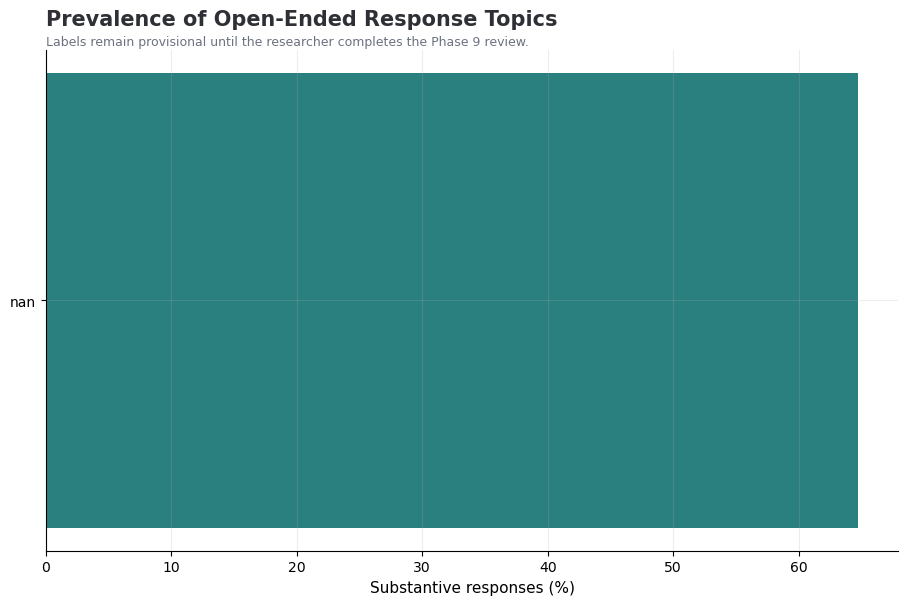

In [14]:
# Cell 10.8.1 — Integrate Reviewed Topics, Response Coverage, and Statistical Evidence

NLP_FINDINGS_PATH = find_table_from_manifest(phase_9, 'primary_phase_10_table', ['data/phase_09_thesis_ready_findings.csv'])
NLP_STATS_PATH = find_table_from_manifest(phase_9, 'statistical_tests_table', ['data/phase_09_statistical_tests.csv'])
NLP_TOPIC_PREVALENCE_PATH = resolve_artifact(None, ['data/phase_09_topic_prevalence.csv'])
NLP_QUESTION_QUALITY_PATH = resolve_artifact(None, ['data/phase_09_question_quality_summary.csv'])

nlp_findings = load_table(NLP_FINDINGS_PATH) if NLP_FINDINGS_PATH else pd.DataFrame()
nlp_statistics = load_table(NLP_STATS_PATH) if NLP_STATS_PATH else pd.DataFrame()
topic_prevalence = load_table(NLP_TOPIC_PREVALENCE_PATH) if NLP_TOPIC_PREVALENCE_PATH else pd.DataFrame()
question_quality = load_table(NLP_QUESTION_QUALITY_PATH) if NLP_QUESTION_QUALITY_PATH else pd.DataFrame()

reviewed_topic_map = {}
if not topic_review.empty and 'topic_id' in topic_review:
    for _, row in topic_review.iterrows():
        confirmed = str(row.get('researcher_confirmed_topic_name', '') or '').strip()
        automatic = str(row.get('automatic_topic_label', '') or '').strip()
        reviewed_topic_map[row['topic_id']] = confirmed if confirmed else automatic

reviewed_topics = topic_prevalence.copy()
if not reviewed_topics.empty:
    reviewed_topics['reporting_topic_name'] = reviewed_topics['topic_id'].map(reviewed_topic_map).fillna(reviewed_topics.get('automatic_topic_label'))
    reviewed_topics['review_status'] = 'Researcher-reviewed' if phase_9_topics_reviewed else 'Automatic label — manual review pending'

significant_nlp_tests = pd.DataFrame()
if not nlp_statistics.empty and 'significant_at_0_05_after_bh' in nlp_statistics:
    mask = nlp_statistics['significant_at_0_05_after_bh'].apply(normalise_bool)
    significant_nlp_tests = nlp_statistics[mask].copy()

FOLDERS = create_cell_folders('10_08', 'NLP_Integration', '10_08_01', 'NLP_Synthesis')
for name, frame in [
    ('10_08_01_response_quality', question_quality),
    ('10_08_01_reviewed_topic_prevalence', reviewed_topics),
    ('10_08_01_nlp_statistical_tests', nlp_statistics),
    ('10_08_01_significant_nlp_tests', significant_nlp_tests),
    ('10_08_01_thesis_ready_findings', nlp_findings),
]:
    save_dataframe(frame, FOLDERS, name)

display(question_quality)
display(reviewed_topics.head(TOP_NLP_TOPICS_TO_REPORT))
print('Manual topic review complete:', phase_9_topics_reviewed)

if not reviewed_topics.empty:
    plot = reviewed_topics.sort_values('response_percentage').tail(TOP_NLP_TOPICS_TO_REPORT)
    fig, ax = plt.subplots(figsize=(11, 6.5))
    ax.barh(plot['reporting_topic_name'], plot['response_percentage'], color=THEME['teal'])
    ax.set_xlabel('Substantive responses (%)')
    style_axis(ax, 'Prevalence of Open-Ended Response Topics', 'Labels remain provisional until the researcher completes the Phase 9 review.', grid_axis='x')
    save_figure(fig, FOLDERS, '10_08_01_topic_prevalence')
    plt.show()


# Section 10.9 — Research Questions and Hypothesis Evidence Matrix


In [15]:
# Cell 10.9.1 — Build an Editable Research-Question Evidence Matrix

# Edit the wording below to match the final approved proposal exactly.
RESEARCH_QUESTIONS = [
    {
        'research_question_id': 'RQ1',
        'research_question': 'How accurately can machine-learning models classify students into Low, Medium, and High academic-performance categories using socio-economic factors?',
        'primary_phases': '4, 6, and 8',
        'principal_evidence': 'Cross-validated Accuracy, Balanced Accuracy, Macro F1, class-wise Recall/F1, and final holdout metrics.',
    },
    {
        'research_question_id': 'RQ2',
        'research_question': 'Which supervised learning model provides the strongest balance of performance, stability, fairness, interpretability, and efficiency?',
        'primary_phases': '4 and 6',
        'principal_evidence': 'Multi-criteria candidate selection, bootstrap confidence intervals, learning curves, error analysis, and fairness gaps.',
    },
    {
        'research_question_id': 'RQ3',
        'research_question': 'Which socio-economic and educational factors contribute most strongly to the model predictions?',
        'primary_phases': '7',
        'principal_evidence': 'Consensus feature importance, SHAP/Shapley analysis, permutation importance, class-specific and cluster-specific explanations.',
    },
    {
        'research_question_id': 'RQ4',
        'research_question': 'Do socio-economic characteristics form meaningful student groups, and how do academic-performance categories vary across those groups?',
        'primary_phases': '5',
        'principal_evidence': 'PCA, K-Means quality and stability measures, cluster profiles, and post-hoc academic-class composition.',
    },
    {
        'research_question_id': 'RQ5',
        'research_question': 'What themes emerge from the open-ended questionnaire responses, and are they associated with academic class or socio-economic clusters?',
        'primary_phases': '9',
        'principal_evidence': 'Response coverage, TF-IDF, reviewed NMF topics, text clusters, and multiplicity-adjusted association tests.',
    },
]

rq_evidence = pd.DataFrame(RESEARCH_QUESTIONS)
rq_evidence['evidence_status'] = [
    'Final evidence available' if phase_8_final else 'Cross-validation available; final holdout pending',
    'Provisional until deep Phase 4 and downstream reruns are frozen' if not phase_4_deep else 'Available',
    'Available; predictive association only',
    'Available; descriptive/post-hoc relationship only',
    'Manual topic review pending' if not phase_9_topics_reviewed else 'Available',
]
rq_evidence['reporting_caution'] = [
    'Do not substitute cross-validation for the final holdout result.',
    'The best model is selected before viewing the final holdout.',
    'Feature importance does not prove causation.',
    'Academic class was excluded from cluster formation.',
    'Automatic topic labels and lexical polarity require cautious qualitative interpretation.',
]

FOLDERS = create_cell_folders('10_09', 'Research_Question_Evidence', '10_09_01', 'Research_Question_Matrix')
save_dataframe(rq_evidence, FOLDERS, '10_09_01_research_question_evidence_matrix')
display(rq_evidence)


,research_question_id,research_question,primary_phases,principal_evidence,evidence_status,reporting_caution
0,RQ1,How accurately can machine-learning models cla...,"4, 6, and 8","Cross-validated Accuracy, Balanced Accuracy, M...",Cross-validation available; final holdout pending,Do not substitute cross-validation for the fin...
1,RQ2,Which supervised learning model provides the s...,4 and 6,"Multi-criteria candidate selection, bootstrap ...",Provisional until deep Phase 4 and downstream ...,The best model is selected before viewing the ...
2,RQ3,Which socio-economic and educational factors c...,7,"Consensus feature importance, SHAP/Shapley ana...",Available; predictive association only,Feature importance does not prove causation.
3,RQ4,Do socio-economic characteristics form meaning...,5,"PCA, K-Means quality and stability measures, c...",Available; descriptive/post-hoc relationship only,Academic class was excluded from cluster forma...
4,RQ5,What themes emerge from the open-ended questio...,9,"Response coverage, TF-IDF, reviewed NMF topics...",Manual topic review pending,Automatic topic labels and lexical polarity re...


In [16]:
# Cell 10.9.2 — Build an Editable Hypothesis-Evidence Template

# Replace these hypotheses with the final approved hypotheses from the proposal.
HYPOTHESIS_TEMPLATE = [
    {'hypothesis_id': 'H1', 'hypothesis': 'Socio-economic and educational factors are associated with academic-performance category.', 'analysis': 'Supervised predictive performance and model explainability.', 'decision_rule': 'Interpret predictive evidence together with uncertainty; do not claim causation.'},
    {'hypothesis_id': 'H2', 'hypothesis': 'Parental education and family income contribute meaningfully to academic-performance prediction.', 'analysis': 'Consensus importance and class-specific SHAP/Shapley evidence.', 'decision_rule': 'Support only when importance is consistent across methods and runs.'},
    {'hypothesis_id': 'H3', 'hypothesis': 'Students can be grouped into distinct socio-economic profiles with different post-hoc academic-class distributions.', 'analysis': 'Cluster validity, stability, profiles, and class composition.', 'decision_rule': 'Require stable clusters and describe association without causal wording.'},
    {'hypothesis_id': 'H4', 'hypothesis': 'Open-ended response themes differ across academic-performance categories or socio-economic clusters.', 'analysis': 'Multiplicity-adjusted Phase 9 association tests.', 'decision_rule': 'Support only when adjusted p < .05 and effect size is substantively meaningful.'},
]
hypothesis_evidence = pd.DataFrame(HYPOTHESIS_TEMPLATE)
hypothesis_evidence['researcher_decision'] = 'Pending final review'
hypothesis_evidence['evidence_reference'] = ['Phases 4, 6, 7, and 8', 'Phase 7', 'Phase 5', 'Phase 9']

FOLDERS = create_cell_folders('10_09', 'Research_Question_Evidence', '10_09_02', 'Hypothesis_Template')
save_dataframe(hypothesis_evidence, FOLDERS, '10_09_02_hypothesis_evidence_template')
display(hypothesis_evidence)


,hypothesis_id,hypothesis,analysis,decision_rule,researcher_decision,evidence_reference
0,H1,Socio-economic and educational factors are ass...,Supervised predictive performance and model ex...,Interpret predictive evidence together with un...,Pending final review,"Phases 4, 6, 7, and 8"
1,H2,Parental education and family income contribut...,Consensus importance and class-specific SHAP/S...,Support only when importance is consistent acr...,Pending final review,Phase 7
2,H3,Students can be grouped into distinct socio-ec...,"Cluster validity, stability, profiles, and cla...",Require stable clusters and describe associati...,Pending final review,Phase 5
3,H4,Open-ended response themes differ across acade...,Multiplicity-adjusted Phase 9 association tests.,Support only when adjusted p < .05 and effect ...,Pending final review,Phase 9


# Section 10.10 — Integrated Findings, Recommendations, and Limitations


In [17]:
# Cell 10.10.1 — Build an Auditable Integrated Findings Table

integrated_rows=[]

if not model_performance_summary.empty:
    best = model_performance_summary.sort_values('Macro F1', ascending=False).iloc[0]
    integrated_rows.append({
        'evidence_domain': 'Supervised learning',
        'finding': f"The strongest currently available cross-validated candidate is {best['model']} ({best['stage']}) with Macro F1={fmt_number(best['Macro F1'])} and Balanced Accuracy={fmt_number(best['Balanced Accuracy'])}.",
        'evidence_source': 'Phases 4 and 6',
        'status': 'Final' if phase_4_deep and phase_8_final else 'Provisional',
        'interpretation_limit': 'Cross-validation is not the final holdout estimate.'
    })

if not cluster_target_comparison.empty:
    low_col = 'Low' if 'Low' in cluster_target_comparison else None
    high_col = 'High' if 'High' in cluster_target_comparison else None
    if low_col and high_col:
        low_row = cluster_target_comparison.loc[cluster_target_comparison[low_col].idxmax()]
        high_row = cluster_target_comparison.loc[cluster_target_comparison[high_col].idxmax()]
        integrated_rows.append({
            'evidence_domain': 'Unsupervised learning',
            'finding': f"{low_row['cluster_name']} had the largest post-hoc Low proportion ({fmt_number(low_row[low_col], 1)}%), while {high_row['cluster_name']} had the largest High proportion ({fmt_number(high_row[high_col], 1)}%).",
            'evidence_source': 'Phase 5',
            'status': 'Available',
            'interpretation_limit': 'The target was not used during clustering; this is a descriptive post-hoc association.'
        })

if not top_features.empty:
    names = ', '.join(top_features['feature'].astype(str).head(5).tolist())
    integrated_rows.append({
        'evidence_domain': 'Explainability',
        'finding': f"The leading consensus predictors were {names}.",
        'evidence_source': 'Phase 7',
        'status': 'Available',
        'interpretation_limit': 'Importance reflects prediction, not causal impact.'
    })

if phase_8_final and not final_metrics.empty:
    metric_map = dict(zip(final_metrics['metric'], final_metrics['value']))
    integrated_rows.append({
        'evidence_domain': 'Final holdout',
        'finding': f"The frozen model achieved final holdout Accuracy={fmt_number(metric_map.get('accuracy'))}, Balanced Accuracy={fmt_number(metric_map.get('balanced_accuracy'))}, and Macro F1={fmt_number(metric_map.get('f1_macro'))}.",
        'evidence_source': 'Phase 8',
        'status': 'Final',
        'interpretation_limit': 'This is the single untouched holdout evaluation.'
    })
else:
    integrated_rows.append({
        'evidence_domain': 'Final holdout',
        'finding': 'The final holdout result is intentionally omitted because Phase 8 remains incomplete or provisional.',
        'evidence_source': 'Phase 8 governance manifest',
        'status': 'Blocked',
        'interpretation_limit': 'No final performance claim may be made yet.'
    })

if not reviewed_topics.empty:
    leading_topic = reviewed_topics.sort_values('response_percentage', ascending=False).iloc[0]
    integrated_rows.append({
        'evidence_domain': 'Open-ended responses',
        'finding': f"The most prevalent current topic label was “{leading_topic['reporting_topic_name']}”, representing {fmt_number(leading_topic['response_percentage'], 1)}% of substantive responses.",
        'evidence_source': 'Phase 9',
        'status': 'Available' if phase_9_topics_reviewed else 'Provisional',
        'interpretation_limit': 'Topic names require researcher review; repeated synthetic or templated responses can distort prevalence.'
    })

integrated_findings = pd.DataFrame(integrated_rows)

recommendations = pd.DataFrame([
    {'recommendation_area': 'Educational support', 'recommendation': 'Use the model only to support human-led early review and targeted assistance; never as an automatic judgement system.', 'evidence_basis': 'Phases 6–8', 'priority': 'High'},
    {'recommendation_area': 'Data quality', 'recommendation': 'Expand representative Bahrain data collection and document sampling, missingness, and subgroup coverage.', 'evidence_basis': 'Phases 1–3 and limitations', 'priority': 'High'},
    {'recommendation_area': 'Model monitoring', 'recommendation': 'Monitor Macro F1, class-specific Recall, calibration, subgroup gaps, and data drift after deployment.', 'evidence_basis': 'Phases 6 and 8', 'priority': 'High'},
    {'recommendation_area': 'Interpretability', 'recommendation': 'Present feature contributions as associations that guide investigation, not proof of causal influence.', 'evidence_basis': 'Phase 7', 'priority': 'High'},
    {'recommendation_area': 'Qualitative follow-up', 'recommendation': 'Review Phase 9 topics manually and use interviews or focus groups to deepen interpretation.', 'evidence_basis': 'Phase 9', 'priority': 'Medium'},
    {'recommendation_area': 'Responsible AI', 'recommendation': 'Require human oversight, access controls, privacy protection, and an appeal or correction route for affected students.', 'evidence_basis': 'Ethics and model card', 'priority': 'High'},
])

limitations = pd.DataFrame([
    {'limitation': 'Questionnaire variables may contain self-reporting and measurement error.', 'consequence': 'Predictive relationships can be attenuated or distorted.', 'mitigation': 'Clear wording, validation, and future linkage with authorised administrative data.'},
    {'limitation': 'Current artifacts may be based on synthetic or provisional data.', 'consequence': 'Results cannot automatically be generalised to Bahrain students.', 'mitigation': 'Rerun the complete pipeline on the approved final dataset and preserve lineage hashes.'},
    {'limitation': 'Class imbalance and subgroup sample size affect class-wise and fairness estimates.', 'consequence': 'Some Recall and gap estimates may be unstable.', 'mitigation': 'Report confidence intervals and minimum subgroup sizes.'},
    {'limitation': 'Feature importance is not causal inference.', 'consequence': 'High importance must not be described as an intervention effect.', 'mitigation': 'Use causal language only with an appropriate causal design.'},
    {'limitation': 'Automatic NLP topic labels may be unstable or semantically incomplete.', 'consequence': 'Topics can be misnamed or overinterpreted.', 'mitigation': 'Researcher review and qualitative validation are mandatory.'},
])

FOLDERS = create_cell_folders('10_10', 'Integrated_Findings_and_Recommendations', '10_10_01', 'Integrated_Evidence')
for name, frame in [('10_10_01_integrated_findings', integrated_findings), ('10_10_01_recommendations', recommendations), ('10_10_01_limitations', limitations)]:
    save_dataframe(frame, FOLDERS, name)

display(integrated_findings)
display(recommendations)


,evidence_domain,finding,evidence_source,status,interpretation_limit
0,Supervised learning,The strongest currently available cross-valida...,Phases 4 and 6,Provisional,Cross-validation is not the final holdout esti...
1,Unsupervised learning,Cluster 3 — Lower relative support had the lar...,Phase 5,Available,The target was not used during clustering; thi...
2,Explainability,The leading consensus predictors were family_i...,Phase 7,Available,"Importance reflects prediction, not causal imp..."
3,Final holdout,The final holdout result is intentionally omit...,Phase 8 governance manifest,Blocked,No final performance claim may be made yet.
4,Open-ended responses,The most prevalent current topic label was “na...,Phase 9,Provisional,Topic names require researcher review; repeate...


,recommendation_area,recommendation,evidence_basis,priority
0,Educational support,Use the model only to support human-led early ...,Phases 6–8,High
1,Data quality,Expand representative Bahrain data collection ...,Phases 1–3 and limitations,High
2,Model monitoring,"Monitor Macro F1, class-specific Recall, calib...",Phases 6 and 8,High
3,Interpretability,Present feature contributions as associations ...,Phase 7,High
4,Qualitative follow-up,Review Phase 9 topics manually and use intervi...,Phase 9,Medium
5,Responsible AI,"Require human oversight, access controls, priv...",Ethics and model card,High


# Section 10.11 — Thesis-Ready Narratives, Tables, Figures, and Workbook


In [18]:
# Cell 10.11.1 — Generate Thesis-Ready Results, Discussion, and Conclusion Drafts

FOLDERS = create_cell_folders('10_11', 'Thesis_Ready_Reporting', '10_11_01', 'Generate_Narrative_Drafts')

best_model_sentence = 'No supervised model result was available.'
if not model_performance_summary.empty:
    best = model_performance_summary.sort_values('Macro F1', ascending=False).iloc[0]
    best_model_sentence = (
        f"Across the currently available family-aware cross-validation results, {best['model']} ({best['stage']}) "
        f"produced Macro F1={fmt_number(best['Macro F1'])}, Balanced Accuracy={fmt_number(best['Balanced Accuracy'])}, "
        f"and Accuracy={fmt_number(best['Accuracy'])}."
    )

holdout_sentence = (
    'The final untouched holdout evaluation has not yet been completed and no final generalisation claim is reported.'
)
if phase_8_final and not final_metrics.empty:
    metric_map = dict(zip(final_metrics['metric'], final_metrics['value']))
    holdout_sentence = (
        f"After the model was frozen, the one-time untouched holdout evaluation produced Accuracy={fmt_number(metric_map.get('accuracy'))}, "
        f"Balanced Accuracy={fmt_number(metric_map.get('balanced_accuracy'))}, and Macro F1={fmt_number(metric_map.get('f1_macro'))}."
    )

feature_sentence = 'Explainability outputs were unavailable.'
if not top_features.empty:
    feature_sentence = 'The leading consensus predictors were ' + ', '.join(top_features['feature'].astype(str).head(5)) + '. These values indicate predictive contribution rather than causation.'

cluster_sentence = 'Cluster results were unavailable.'
if not cluster_target_comparison.empty:
    cluster_sentence = f"Phase 5 identified {phase_5.get('selected_cluster_count')} socio-economic clusters. Academic-performance categories were added only after clustering for descriptive interpretation."

nlp_sentence = 'NLP outputs were unavailable.'
if not reviewed_topics.empty:
    nlp_sentence = f"Phase 9 identified {len(reviewed_topics)} text topics from substantive responses. Topic labels are {'researcher-reviewed' if phase_9_topics_reviewed else 'automatic and pending researcher review'}."

results_markdown = f'''# Chapter 4 — Results Draft

> **{DRAFT_BANNER}**

## 4.1 Data preparation and experimental design

The analysis used {phase_3.get('training_records', 'N/A')} training records and reserved {phase_3.get('holdout_records', 'N/A')} records as an untouched holdout. The split was performed at family level, with a recorded family overlap of {phase_3.get('family_overlap', 'N/A')}. Five family-aware validation folds were used for model development. The principal model-selection metric was Macro F1, supported by Accuracy, Balanced Accuracy, class-specific Precision, Recall, and F1-score, probability-based metrics, robustness checks, and subgroup analysis.

## 4.2 Supervised model results

{best_model_sentence}

Hyperparameter effects must be reported separately for every algorithm using the Baseline and Tuned rows. A Tuned version is not automatically preferred when its independently evaluated outer-fold result is weaker.

## 4.3 Unsupervised socio-economic profiles

{cluster_sentence}

## 4.4 Model explainability

{feature_sentence}

## 4.5 Final untouched holdout evaluation

{holdout_sentence}

## 4.6 Open-ended response analysis

{nlp_sentence}

## 4.7 Summary

The numerical findings in this draft must be refreshed after the final approved Phase 4–Phase 9 run. Tables and figures generated by this notebook retain their phase provenance and reporting status.
'''

discussion_markdown = f'''# Chapter 5 — Discussion Scaffold

> **{DRAFT_BANNER}**

## 5.1 Interpretation of predictive performance

Discuss whether the final Macro F1, Balanced Accuracy, and class-specific Recall are sufficient for a decision-support setting. Compare the final findings with the reviewed literature using the original IEEE reference numbering. **[Insert evidence-based comparison with citations.]**

## 5.2 Effect of hyperparameter tuning

Explain which algorithms improved after deep tuning, which did not, and why the independently evaluated Tuned result should be preferred only when it is stronger and stable. **[Insert model-specific evidence from the Phase 4 comparison table.]**

## 5.3 Socio-economic profiles and influential factors

{feature_sentence} {cluster_sentence} Discuss whether these patterns agree with or differ from Bahrain, GCC, Arab, and international studies. Avoid converting predictive importance into a causal claim. **[Insert IEEE citations.]**

## 5.4 Fairness, error safety, and responsible use

Interpret subgroup gaps together with subgroup sample sizes and confidence intervals. Emphasise that predictions are intended for human-reviewed support, not punishment, exclusion, or automatic labelling.

## 5.5 Open-ended responses

{nlp_sentence} Integrate the reviewed topics with the quantitative results and identify where qualitative follow-up is needed.

## 5.6 Limitations

Discuss sampling, representativeness, self-reporting, synthetic-data status where applicable, class imbalance, subgroup uncertainty, non-causal explainability, and topic-model review requirements.
'''

conclusion_markdown = f'''# Chapter 6 — Conclusions and Recommendations Draft

> **{DRAFT_BANNER}**

This study designed an auditable machine-learning workflow for analysing student academic-performance categories using socio-economic and educational variables in Bahrain. The workflow combined supervised learning, family-aware validation, hyperparameter tuning, unsupervised profiling, robustness and fairness analysis, explainability, locked holdout governance, and open-ended response analysis.

The final conclusion must be written only after all final-reporting gates pass. Current practical recommendations prioritise human oversight, targeted support, privacy protection, continuous monitoring, representative local data, and cautious interpretation of feature importance and NLP themes.
'''

narrative_files = {
    'phase_10_results_chapter_draft.md': results_markdown,
    'phase_10_discussion_chapter_scaffold.md': discussion_markdown,
    'phase_10_conclusion_recommendations_draft.md': conclusion_markdown,
}
for filename, content in narrative_files.items():
    (FOLDERS['reports'] / filename).write_text(content, encoding='utf-8')
    (PHASE_DIR / filename).write_text(content, encoding='utf-8')

print(results_markdown[:3000])


# Chapter 4 — Results Draft

> **PROVISIONAL DRAFT — NOT FOR FINAL THESIS SUBMISSION**

## 4.1 Data preparation and experimental design

The analysis used 2006 training records and reserved 494 records as an untouched holdout. The split was performed at family level, with a recorded family overlap of 0. Five family-aware validation folds were used for model development. The principal model-selection metric was Macro F1, supported by Accuracy, Balanced Accuracy, class-specific Precision, Recall, and F1-score, probability-based metrics, robustness checks, and subgroup analysis.

## 4.2 Supervised model results

Across the currently available family-aware cross-validation results, Logistic Regression (Baseline) produced Macro F1=0.5528, Balanced Accuracy=0.5383, and Accuracy=0.5890.

Hyperparameter effects must be reported separately for every algorithm using the Baseline and Tuned rows. A Tuned version is not automatically preferred when its independently evaluated outer-fold result is w

In [19]:
# Cell 10.11.2 — Build Thesis Table and Figure Catalogues

FOLDERS = create_cell_folders('10_11', 'Thesis_Ready_Reporting', '10_11_02', 'Table_and_Figure_Catalogues')

thesis_tables = pd.DataFrame([
    {'proposed_table': 'Dataset and experimental-design summary', 'source_table': '10_03_01_dataset_profile.csv', 'chapter_section': 'Results — data preparation', 'status': 'Ready'},
    {'proposed_table': 'Cross-validated candidate-model comparison', 'source_table': '10_04_01_model_performance_summary.csv', 'chapter_section': 'Results — supervised models', 'status': 'Provisional' if not phase_4_deep else 'Ready'},
    {'proposed_table': 'Baseline-versus-Tuned metric comparison', 'source_table': '10_04_02_baseline_vs_tuned_metric_comparison.csv', 'chapter_section': 'Results — tuning effects', 'status': 'Ready' if not baseline_tuned_comparison.empty else 'Source unavailable'},
    {'proposed_table': 'Model robustness and fairness summary', 'source_table': str(PHASE_6_FAIRNESS_PATH), 'chapter_section': 'Results — quality checking', 'status': 'Ready' if PHASE_6_FAIRNESS_PATH else 'Unavailable'},
    {'proposed_table': 'Socio-economic cluster profiles', 'source_table': '10_05_01_cluster_profiles.csv', 'chapter_section': 'Results — unsupervised analysis', 'status': 'Ready'},
    {'proposed_table': 'Consensus predictor importance', 'source_table': '10_06_01_top_consensus_features.csv', 'chapter_section': 'Results — explainability', 'status': 'Ready'},
    {'proposed_table': 'Final holdout metrics', 'source_table': '10_07_01_final_metrics.csv', 'chapter_section': 'Results — final evaluation', 'status': 'Ready' if phase_8_final else 'Blocked'},
    {'proposed_table': 'Reviewed NLP topics and prevalence', 'source_table': '10_08_01_reviewed_topic_prevalence.csv', 'chapter_section': 'Results — open-ended responses', 'status': 'Ready' if phase_9_topics_reviewed else 'Manual review pending'},
    {'proposed_table': 'Research-question evidence matrix', 'source_table': '10_09_01_research_question_evidence_matrix.csv', 'chapter_section': 'Results summary', 'status': 'Ready'},
])

figure_paths = sorted(PHASE_DIR.rglob('*.png'))
figure_catalogue = pd.DataFrame([
    {
        'figure_number_placeholder': f'Figure X.{index}',
        'figure_file': path.name,
        'path': str(path),
        'suggested_caption': path.stem.replace('_', ' '),
        'reporting_status': 'Final' if FINAL_REPORT_READY else 'Provisional',
    }
    for index, path in enumerate(figure_paths, start=1)
])

save_dataframe(thesis_tables, FOLDERS, '10_11_02_thesis_table_catalogue')
save_dataframe(figure_catalogue, FOLDERS, '10_11_02_figure_catalogue')
display(thesis_tables)
display(figure_catalogue.head(20))


,proposed_table,source_table,chapter_section,status
0,Dataset and experimental-design summary,10_03_01_dataset_profile.csv,Results — data preparation,Ready
1,Cross-validated candidate-model comparison,10_04_01_model_performance_summary.csv,Results — supervised models,Provisional
2,Baseline-versus-Tuned metric comparison,10_04_02_baseline_vs_tuned_metric_comparison.csv,Results — tuning effects,Ready
3,Model robustness and fairness summary,C:\Users\User\Desktop\All\data\phase_06_fairne...,Results — quality checking,Ready
4,Socio-economic cluster profiles,10_05_01_cluster_profiles.csv,Results — unsupervised analysis,Ready
5,Consensus predictor importance,10_06_01_top_consensus_features.csv,Results — explainability,Ready
6,Final holdout metrics,10_07_01_final_metrics.csv,Results — final evaluation,Blocked
7,Reviewed NLP topics and prevalence,10_08_01_reviewed_topic_prevalence.csv,Results — open-ended responses,Manual review pending
8,Research-question evidence matrix,10_09_01_research_question_evidence_matrix.csv,Results summary,Ready


,figure_number_placeholder,figure_file,path,suggested_caption,reporting_status
0,Figure X.1,10_02_02_phase_readiness.png,C:\Users\User\Desktop\All\outputs\Phase_10_Fin...,10 02 02 phase readiness,Provisional
1,Figure X.2,10_03_01_class_distribution.png,C:\Users\User\Desktop\All\outputs\Phase_10_Fin...,10 03 01 class distribution,Provisional
2,Figure X.3,10_04_03_candidate_macro_f1.png,C:\Users\User\Desktop\All\outputs\Phase_10_Fin...,10 04 03 candidate macro f1,Provisional
3,Figure X.4,10_04_03_macro_f1_tuning_effect.png,C:\Users\User\Desktop\All\outputs\Phase_10_Fin...,10 04 03 macro f1 tuning effect,Provisional
4,Figure X.5,10_04_03_mean_fairness_gap.png,C:\Users\User\Desktop\All\outputs\Phase_10_Fin...,10 04 03 mean fairness gap,Provisional
5,Figure X.6,10_05_01_cluster_target_composition.png,C:\Users\User\Desktop\All\outputs\Phase_10_Fin...,10 05 01 cluster target composition,Provisional
6,Figure X.7,10_06_01_feature_group_importance.png,C:\Users\User\Desktop\All\outputs\Phase_10_Fin...,10 06 01 feature group importance,Provisional
7,Figure X.8,10_06_01_top_consensus_features.png,C:\Users\User\Desktop\All\outputs\Phase_10_Fin...,10 06 01 top consensus features,Provisional
8,Figure X.9,10_08_01_topic_prevalence.png,C:\Users\User\Desktop\All\outputs\Phase_10_Fin...,10 08 01 topic prevalence,Provisional


In [20]:
# Cell 10.11.3 — Export the Consolidated Phase 10 Workbook

FOLDERS = create_cell_folders('10_11', 'Thesis_Ready_Reporting', '10_11_03', 'Consolidated_Workbook')
CONSOLIDATED_WORKBOOK_PATH = PROJECT_ROOT / 'Phase_10_Consolidated_Reports.xlsx'

workbook_tables = {
    'Reporting Status': reporting_gates,
    'Phase Inventory': phase_inventory,
    'Lineage Summary': lineage_summary,
    'Dataset Profile': dataset_profile,
    'Class Distribution': class_distribution,
    'Model Performance': model_performance_summary,
    'Baseline vs Tuned': baseline_tuned_comparison,
    'Tuning Summary': tuning_model_summary,
    'Fairness Gaps': phase_6_fairness,
    'Cluster Summary': cluster_method_summary,
    'Cluster Profiles': cluster_profiles,
    'Cluster Target': cluster_target_comparison,
    'Top Features': top_features,
    'Holdout Status': holdout_status,
    'Final Metrics': final_metrics,
    'Per-Class Metrics': per_class_metrics,
    'NLP Question Quality': question_quality,
    'NLP Topics': reviewed_topics,
    'NLP Tests': nlp_statistics,
    'Research Questions': rq_evidence,
    'Hypotheses': hypothesis_evidence,
    'Integrated Findings': integrated_findings,
    'Recommendations': recommendations,
    'Limitations': limitations,
    'Table Catalogue': thesis_tables,
    'Figure Catalogue': figure_catalogue,
}

if EXPORT_EXCEL_WORKBOOK:
    with pd.ExcelWriter(CONSOLIDATED_WORKBOOK_PATH, engine='openpyxl') as writer:
        for sheet_name, frame in workbook_tables.items():
            frame_to_write = frame if isinstance(frame, pd.DataFrame) else pd.DataFrame(frame)
            frame_to_write.to_excel(writer, sheet_name=sheet_name[:31], index=False)
        status_sheet = pd.DataFrame([
            {'item': 'Project title', 'value': PROJECT_TITLE},
            {'item': 'Reporting mode', 'value': REPORTING_MODE},
            {'item': 'Final report ready', 'value': FINAL_REPORT_READY},
            {'item': 'Banner', 'value': DRAFT_BANNER},
            {'item': 'Generated at', 'value': datetime.now().isoformat()},
        ])
        status_sheet.to_excel(writer, sheet_name='README', index=False)
    shutil.copy2(CONSOLIDATED_WORKBOOK_PATH, FOLDERS['files'] / CONSOLIDATED_WORKBOOK_PATH.name)
    print('Consolidated workbook:', CONSOLIDATED_WORKBOOK_PATH)


Consolidated workbook: C:\Users\User\Desktop\All\Phase_10_Consolidated_Reports.xlsx


# Section 10.12 — Final Quality Checks, Exports, and Phase 11 Handoff


In [21]:
# Cell 10.12.1 — Run Phase 10 Quality Checks

quality_checks=[]
def add_check(name, passed, details, final_blocker=False):
    quality_checks.append({'quality_check': name, 'passed': bool(passed), 'details': str(details), 'final_blocker': bool(final_blocker)})

add_check('Reporting-governance table created', not reporting_gates.empty, len(reporting_gates), True)
add_check('Phase manifests inventoried', len(manifest_inventory) == len(MANIFEST_SPECS), len(manifest_inventory), True)
add_check('Family overlap is zero', int(phase_3.get('family_overlap', 1)) == 0, phase_3.get('family_overlap'), True)
add_check('Holdout remained sealed before Phase 8', holdout_sealed_before_phase_8, holdout_sealed_before_phase_8, True)
add_check('Model performance summary available', not model_performance_summary.empty, len(model_performance_summary), True)
add_check('Cluster integration available', not cluster_target_comparison.empty, len(cluster_target_comparison), False)
add_check('Explainability integration available', not top_features.empty, len(top_features), True)
add_check('NLP integration available', not nlp_findings.empty or not reviewed_topics.empty, len(nlp_findings), False)
add_check('Research-question evidence matrix created', len(rq_evidence) >= 5, len(rq_evidence), True)
add_check('Narrative drafts created', all((PHASE_DIR / name).exists() for name in narrative_files), list(narrative_files), True)
add_check('Consolidated workbook created', (not EXPORT_EXCEL_WORKBOOK) or CONSOLIDATED_WORKBOOK_PATH.exists(), CONSOLIDATED_WORKBOOK_PATH, False)
add_check('Final thesis gates passed', FINAL_REPORT_READY, reporting_gates.loc[~reporting_gates['passed'], 'gate'].tolist(), True)

quality_checks_table = pd.DataFrame(quality_checks)
FOLDERS = create_cell_folders('10_12', 'Quality_Checks_and_Handoff', '10_12_01', 'Quality_Checks')
save_dataframe(quality_checks_table, FOLDERS, '10_12_01_phase_10_quality_checks')
save_json(quality_checks, FOLDERS['reports'] / '10_12_01_phase_10_quality_checks.json')
display(quality_checks_table)

# In DRAFT mode, final blockers are reported rather than raised.
if REPORTING_MODE == 'FINAL_THESIS':
    failed = quality_checks_table.loc[quality_checks_table['final_blocker'] & ~quality_checks_table['passed'], 'quality_check'].tolist()
    if failed:
        raise AssertionError('Final Phase 10 quality checks failed: ' + '; '.join(failed))


,quality_check,passed,details,final_blocker
0,Reporting-governance table created,True,10,True
1,Phase manifests inventoried,True,8,True
2,Family overlap is zero,True,0,True
3,Holdout remained sealed before Phase 8,True,True,True
4,Model performance summary available,True,4,True
5,Cluster integration available,True,3,False
6,Explainability integration available,True,12,True
7,NLP integration available,True,15,False
8,Research-question evidence matrix created,True,5,True
9,Narrative drafts created,True,"['phase_10_results_chapter_draft.md', 'phase_1...",True


In [22]:
# Cell 10.12.2 — Export Official Phase 10 Tables, Manifest, and Complete ZIP

FOLDERS = create_cell_folders('10_12', 'Quality_Checks_and_Handoff', '10_12_02', 'Official_Exports_and_Handoff')

official_tables = {
    'phase_10_reporting_governance_gates.csv': reporting_gates,
    'phase_10_phase_inventory.csv': phase_inventory,
    'phase_10_lineage_summary.csv': lineage_summary,
    'phase_10_dataset_profile.csv': dataset_profile,
    'phase_10_model_performance_summary.csv': model_performance_summary,
    'phase_10_baseline_vs_tuned_comparison.csv': baseline_tuned_comparison,
    'phase_10_tuning_improvement_summary.csv': tuning_model_summary,
    'phase_10_cluster_summary.csv': cluster_method_summary,
    'phase_10_cluster_target_comparison.csv': cluster_target_comparison,
    'phase_10_top_consensus_features.csv': top_features,
    'phase_10_final_holdout_status.csv': holdout_status,
    'phase_10_final_metrics.csv': final_metrics,
    'phase_10_per_class_metrics.csv': per_class_metrics,
    'phase_10_reviewed_nlp_topics.csv': reviewed_topics,
    'phase_10_research_question_evidence_matrix.csv': rq_evidence,
    'phase_10_hypothesis_evidence_template.csv': hypothesis_evidence,
    'phase_10_integrated_findings.csv': integrated_findings,
    'phase_10_recommendations.csv': recommendations,
    'phase_10_limitations.csv': limitations,
    'phase_10_thesis_table_catalogue.csv': thesis_tables,
    'phase_10_figure_catalogue.csv': figure_catalogue,
    'phase_10_quality_checks.csv': quality_checks_table,
}
exported=[]
for filename, frame in official_tables.items():
    path = OFFICIAL_DATA_DIR / filename
    frame.to_csv(path, index=False, encoding='utf-8-sig')
    exported.append(path)

phase_11_handoff = {
    'completed_phase': 'Phase 10 — Final Results Integration and Thesis Reporting',
    'reporting_mode': REPORTING_MODE,
    'final_report_ready': FINAL_REPORT_READY,
    'reporting_banner': DRAFT_BANNER,
    'next_phase': 'Phase 11 — Deployment and Prediction Interface' if FINAL_REPORT_READY else 'Resolve failed final-reporting gates, then rerun Phase 10',
    'data_source': data_source,
    'phase_4_deep_tuning_frozen': phase_4_deep,
    'phase_8_final_holdout_completed': phase_8_final,
    'phase_9_topics_manually_reviewed': phase_9_topics_reviewed,
    'locked_model': phase_8.get('locked_model', phase_7.get('phase_6_primary_candidate', {}).get('model')),
    'locked_stage': phase_8.get('locked_stage', phase_7.get('phase_6_primary_candidate', {}).get('stage')),
    'final_model_bundle': phase_8.get('final_model_bundle') if phase_8_final else None,
    'consolidated_workbook': str(CONSOLIDATED_WORKBOOK_PATH) if EXPORT_EXCEL_WORKBOOK else None,
    'results_chapter_draft': str(PHASE_DIR / 'phase_10_results_chapter_draft.md'),
    'discussion_scaffold': str(PHASE_DIR / 'phase_10_discussion_chapter_scaffold.md'),
    'conclusion_draft': str(PHASE_DIR / 'phase_10_conclusion_recommendations_draft.md'),
    'research_question_evidence_matrix': str(OFFICIAL_DATA_DIR / 'phase_10_research_question_evidence_matrix.csv'),
    'quality_checks': str(OFFICIAL_DATA_DIR / 'phase_10_quality_checks.csv'),
    'generated_at': datetime.now().isoformat(),
}
HANDOFF_PATH = PHASE_DIR / 'phase_10_handoff_manifest_for_phase_11.json'
save_json(phase_11_handoff, HANDOFF_PATH)
shutil.copy2(HANDOFF_PATH, PROJECT_ROOT / HANDOFF_PATH.name)
exported.append(HANDOFF_PATH)

ZIP_PATH = PROJECT_ROOT / 'Phase_10_Complete_Export.zip'
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(PHASE_DIR.rglob('*')):
        if path.is_file():
            archive.write(path, path.relative_to(PHASE_DIR.parent))
    for path in exported:
        if Path(path).exists():
            archive.write(path, Path('official_data') / Path(path).name)
    if EXPORT_EXCEL_WORKBOOK and CONSOLIDATED_WORKBOOK_PATH.exists():
        archive.write(CONSOLIDATED_WORKBOOK_PATH, CONSOLIDATED_WORKBOOK_PATH.name)

completion_summary = {
    'reporting_mode': REPORTING_MODE,
    'final_report_ready': FINAL_REPORT_READY,
    'phase_4_deep_tuning_frozen': phase_4_deep,
    'phase_8_final_holdout_completed': phase_8_final,
    'phase_9_topics_manually_reviewed': phase_9_topics_reviewed,
    'official_tables': len(official_tables),
    'figures': len(figure_catalogue),
    'archive': str(ZIP_PATH),
}
save_json(completion_summary, FOLDERS['reports'] / '10_12_02_completion_summary.json')
print(json.dumps(completion_summary, ensure_ascii=False, indent=2))
print('Phase 11 handoff:', HANDOFF_PATH)
print('Complete archive:', ZIP_PATH)


{
  "reporting_mode": "DRAFT_INTEGRATION",
  "final_report_ready": false,
  "phase_4_deep_tuning_frozen": false,
  "phase_8_final_holdout_completed": false,
  "phase_9_topics_manually_reviewed": false,
  "official_tables": 22,
  "figures": 9,
  "archive": "C:\\Users\\User\\Desktop\\All\\Phase_10_Complete_Export.zip"
}
Phase 11 handoff: C:\Users\User\Desktop\All\outputs\Phase_10_Final_Results_Integration_and_Thesis_Reporting\phase_10_handoff_manifest_for_phase_11.json
Complete archive: C:\Users\User\Desktop\All\Phase_10_Complete_Export.zip


# Phase 10 Completed

The notebook has integrated the available evidence and exported a full audit trail. In `DRAFT_INTEGRATION` mode, failed final-reporting gates are preserved visibly rather than hidden. Change to `FINAL_THESIS` only after the deep Phase 4 run and downstream Phases 6–9 have been rerun, Phase 8 has completed the one-time holdout evaluation, and Phase 9 topic names have been reviewed.
